# Myanmar Sign Language (MSL) Recognition for Emergency Domain
## 5-fold Cross Validation - Version 1.0
## Runtime Environment: Kaggle (T4 GPU)

## Setup

### Path Setup

In [1]:
# copy files in dataset dir to working dir of a session
import shutil
import os

src = "/kaggle/input/datasets/lawunnannda/msl4emergency-dataset-augmented-keypoints"
dst = "/kaggle/working/"

shutil.copytree(src, dst, dirs_exist_ok=True)

'/kaggle/working/'

In [2]:
%pwd

'/kaggle/working'

In [3]:
!ls

annotations.txt  config     label_map.json  sample4infer  src	    wandb
augmented	 keypoints  results	    scripts	  state.db


In [4]:
# create data/ and move files to match paths in config
!mkdir data/
!mv augmented/ sample4infer/ annotations.txt label_map.json data/

In [5]:
!ls

config	data  keypoints  results  scripts  src	state.db  wandb


In [6]:
from pathlib import Path

ROOT = Path(dst).resolve()
KP_DIR = ROOT / "data" / "keypoints"

CONFIG = ROOT / "config" / "config.yaml"
AUG_DIR = ROOT / "data" / "augmented"
SCRIPTS_DIR = ROOT / "scripts"
SRC_DIR = ROOT / "src"
RESULTS_DIR = ROOT / "results"

DATA_ROOT = Path(src).resolve()
REAL_KP_DIR = DATA_ROOT / "keypoints"

In [7]:
# symlink for keypoints
!ln -sfn {REAL_KP_DIR} {KP_DIR}

# verify a symlink
!ls -la {KP_DIR}

lrwxrwxrwx 1 root root 86 Jun 22 08:37 /kaggle/working/data/keypoints -> /kaggle/input/datasets/lawunnannda/msl4emergency-dataset-augmented-keypoints/keypoints


In [8]:
# final check
%cd {ROOT}
!echo
!ls
!echo
!ls {ROOT}/"data"

/kaggle/working

config	data  keypoints  results  scripts  src	state.db  wandb

annotations.txt  augmented  keypoints  label_map.json  sample4infer


In [9]:
# check scripts
!ls -l {SCRIPTS_DIR}

total 60
-rw-r--r-- 1 root root 3868 Jun 21 22:59 00_setup_env.sh
-rw-r--r-- 1 root root 2999 Jun 21 22:59 01_prepare_data.sh
-rw-r--r-- 1 root root 2695 Jun 21 22:59 02_extract_keypoints.sh
-rw-r--r-- 1 root root 2971 Jun 21 22:59 03_augment_data.sh
-rw-r--r-- 1 root root 3162 Jun 21 22:59 04_train.sh
-rw-r--r-- 1 root root 2696 Jun 21 22:59 05_evaluate.sh
-rw-r--r-- 1 root root 4880 Jun 21 22:59 06_run_all_experiments.sh
-rw-r--r-- 1 root root 3310 Jun 21 22:59 07_cross_validate.sh
-rw-r--r-- 1 root root 2625 Jun 21 22:59 08_infer.sh
-rw-r--r-- 1 root root  642 Jun 21 22:59 09_tensorboard.sh
-rw-r--r-- 1 root root 2160 Jun 21 22:59 compare_results.py
-rw-r--r-- 1 root root 5709 Jun 21 22:59 error_analysis.py
-rw-r--r-- 1 root root  725 Jun 21 22:59 move_videos.sh


### Library Setup

In [10]:
import numpy as np
import wandb
import kagglehub
from IPython.display import Image, display

### Weights & Biases (Wandb) Setup

In [11]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
wandb_api = user_secrets.get_secret("WANDB_API_KEY")

In [12]:
!wandb login --relogin {wandb_api}

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


### Files Setup

In [13]:
# check augmented data
%cd {ROOT}
!ls "{AUG_DIR}"

/kaggle/working
augmented_manifest.json  train	val


In [14]:
# check manifest file
!cat "{AUG_DIR}/augmented_manifest.json" | tail -n 20

      "normal_text": "ဟင့်အင်း ၊ သတိ မ လစ် ပါ ဘူး ။",
      "msl_gloss": "သတိလစ် မဟုတ်ဘူး သတိ ရတယ်",
      "label": "သတိလစ် မဟုတ်ဘူး သတိ ရတယ်",
      "video_path": "data/videos/501-558/idx20-557.mp4",
      "keypoint_path": "data/keypoints/501-558/idx20-557.npy",
      "is_augmented": false,
      "split": "test"
    },
    {
      "idx": 557,
      "normal_text": "ဆရာဝန် ဘယ် အချိန် လာ မှာ လဲ ။",
      "msl_gloss": "ဆရာဝန် လာ အချိန် ဘယ်လောက်လဲ",
      "label": "ဆရာဝန် လာ အချိန် ဘယ်လောက်လဲ",
      "video_path": "data/videos/501-558/idx20-558.mp4",
      "keypoint_path": "data/keypoints/501-558/idx20-558.npy",
      "is_augmented": false,
      "split": "test"
    }
  ]
}

In [15]:
# check augmented training data
!ls "{AUG_DIR}/train/" | head -n 5

0000_aug001.npy
0000_aug002.npy
0000_aug003.npy
0000_aug004.npy
0000_aug005.npy
ls: write error: Broken pipe


In [16]:
# check augmented validation data
!ls "{AUG_DIR}/val/" | head -n 5

0000_aug000.npy
0001_aug000.npy
0002_aug000.npy
0003_aug000.npy
0004_aug000.npy


## 7. Training with Cross Validation

In [17]:
!cat {CONFIG} | head -n 12

# ============================================================
# Myanmar Sign Language Recognition - Configuration
# ============================================================

data:
  video_dir: "data/videos"
  keypoint_dir: "data/keypoints"
  augmented_dir: "data/augmented"
  annotation_file: "data/annotations.txt"
  label_map_file: "data/label_map.json"
  split_file: "data/splits.json"



### BiLSTM Model

In [18]:
!time bash {SCRIPTS_DIR}/07_cross_validate.sh bilstm exp_cv_bilstm 5

 K-Fold Cross-Validation
 Model  : bilstm
 Exp    : exp_cv_bilstm
 Folds  : 5
 W&B    : yes

 Aug train pool : 10602 samples (all classes, folded into 5 folds)
 Test set       : 558 originals (fixed across all folds)

2026-06-21 23:11:30.309556: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782083490.519568     406 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782083490.582153     406 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782083491.116529     406 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782083491.116591     406 comput

### Transformer Model

In [19]:
!time bash {SCRIPTS_DIR}/07_cross_validate.sh transformer exp_cv_transformer 5

 K-Fold Cross-Validation
 Model  : transformer
 Exp    : exp_cv_transformer
 Folds  : 5
 W&B    : yes

 Aug train pool : 10602 samples (all classes, folded into 5 folds)
 Test set       : 558 originals (fixed across all folds)

2026-06-22 08:50:53.187822: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782118253.211635     236 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782118253.219551     236 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782118253.239980     236 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782118253.240007     

### Spatial-Temporal Graph Convolutional Network (ST-GCN) Model

In [20]:
!time bash {SCRIPTS_DIR}/07_cross_validate.sh stgcn exp_cv_stgcn 5

 K-Fold Cross-Validation
 Model  : stgcn
 Exp    : exp_cv_stgcn
 Folds  : 5
 W&B    : yes

 Aug train pool : 10602 samples (all classes, folded into 5 folds)
 Test set       : 558 originals (fixed across all folds)

2026-06-22 19:16:30.803253: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782155791.238482     167 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782155791.351523     167 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782155792.353923     167 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782155792.353964     167 computat

In [21]:
!time bash {SCRIPTS_DIR}/07_cross_validate.sh stgcn exp_cv_stgcn 5 "--fold_start 4"

 K-Fold Cross-Validation
 Model  : stgcn
 Exp    : exp_cv_stgcn
 Folds  : 5
 W&B    : yes

 Aug train pool : 10602 samples (all classes, folded into 5 folds)
 Test set       : 558 originals (fixed across all folds)

2026-06-23 07:47:52.087216: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782200872.110321     226 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782200872.117998     226 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782200872.137825     226 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782200872.137856     226 computat

In [22]:
# compute 5-fold cv for stgcn manually # results only include fold 04, not from fold 00 to 03

## Plot

In [23]:
!python {SRC_DIR}/plot_results_v2.py \
  --exp {RESULTS_DIR}/exp_cv_bilstm/fold_00 \
       {RESULTS_DIR}/exp_cv_bilstm/fold_01 \
       {RESULTS_DIR}/exp_cv_bilstm/fold_02 \
       {RESULTS_DIR}/exp_cv_bilstm/fold_03 \
       {RESULTS_DIR}/exp_cv_bilstm/fold_04

Training curves saved → results/exp_cv_bilstm/fold_00/training_curves.png
Training curves saved → results/exp_cv_bilstm/fold_01/training_curves.png
Training curves saved → results/exp_cv_bilstm/fold_02/training_curves.png
Training curves saved → results/exp_cv_bilstm/fold_03/training_curves.png
Training curves saved → results/exp_cv_bilstm/fold_04/training_curves.png
Val comparison chart saved → results/comparison_val.png
[WARNING] No valid test data in results/exp_cv_bilstm/fold_00, skipping
[WARNING] No valid test data in results/exp_cv_bilstm/fold_01, skipping
[WARNING] No valid test data in results/exp_cv_bilstm/fold_02, skipping
[WARNING] No valid test data in results/exp_cv_bilstm/fold_03, skipping
[WARNING] No valid test data in results/exp_cv_bilstm/fold_04, skipping
No experiment data found for split 'test'.


In [24]:
!python {SRC_DIR}/plot_results_v2.py \
  --exp {RESULTS_DIR}/exp_cv_transformer/fold_00 \
       {RESULTS_DIR}/exp_cv_transformer/fold_01 \
       {RESULTS_DIR}/exp_cv_transformer/fold_02 \
       {RESULTS_DIR}/exp_cv_transformer/fold_03 \
       {RESULTS_DIR}/exp_cv_transformer/fold_04

Training curves saved → results/exp_cv_transformer/fold_00/training_curves.png
Training curves saved → results/exp_cv_transformer/fold_01/training_curves.png
Training curves saved → results/exp_cv_transformer/fold_02/training_curves.png
Training curves saved → results/exp_cv_transformer/fold_03/training_curves.png
Training curves saved → results/exp_cv_transformer/fold_04/training_curves.png
Val comparison chart saved → results/comparison_val.png
[WARNING] No valid test data in results/exp_cv_transformer/fold_00, skipping
[WARNING] No valid test data in results/exp_cv_transformer/fold_01, skipping
[WARNING] No valid test data in results/exp_cv_transformer/fold_02, skipping
[WARNING] No valid test data in results/exp_cv_transformer/fold_03, skipping
[WARNING] No valid test data in results/exp_cv_transformer/fold_04, skipping
No experiment data found for split 'test'.


In [25]:
!python {SRC_DIR}/plot_results_v2.py \
  --exp {RESULTS_DIR}/exp_cv_stgcn/fold_00 \
       {RESULTS_DIR}/exp_cv_stgcn/fold_01 \
       {RESULTS_DIR}/exp_cv_stgcn/fold_02 \
       {RESULTS_DIR}/exp_cv_stgcn/fold_03 \
       {RESULTS_DIR}/exp_cv_stgcn/fold_04

Training curves saved → results/exp_cv_stgcn/fold_00/training_curves.png
Training curves saved → results/exp_cv_stgcn/fold_01/training_curves.png
Training curves saved → results/exp_cv_stgcn/fold_02/training_curves.png
Training curves saved → results/exp_cv_stgcn/fold_03/training_curves.png
Training curves saved → results/exp_cv_stgcn/fold_04/training_curves.png
Val comparison chart saved → results/comparison_val.png
[WARNING] No valid test data in results/exp_cv_stgcn/fold_00, skipping
[WARNING] No valid test data in results/exp_cv_stgcn/fold_01, skipping
[WARNING] No valid test data in results/exp_cv_stgcn/fold_02, skipping
[WARNING] No valid test data in results/exp_cv_stgcn/fold_03, skipping
[WARNING] No valid test data in results/exp_cv_stgcn/fold_04, skipping
No experiment data found for split 'test'.


### Training Curves

#### BiLSTM 5-fold Cross Validation

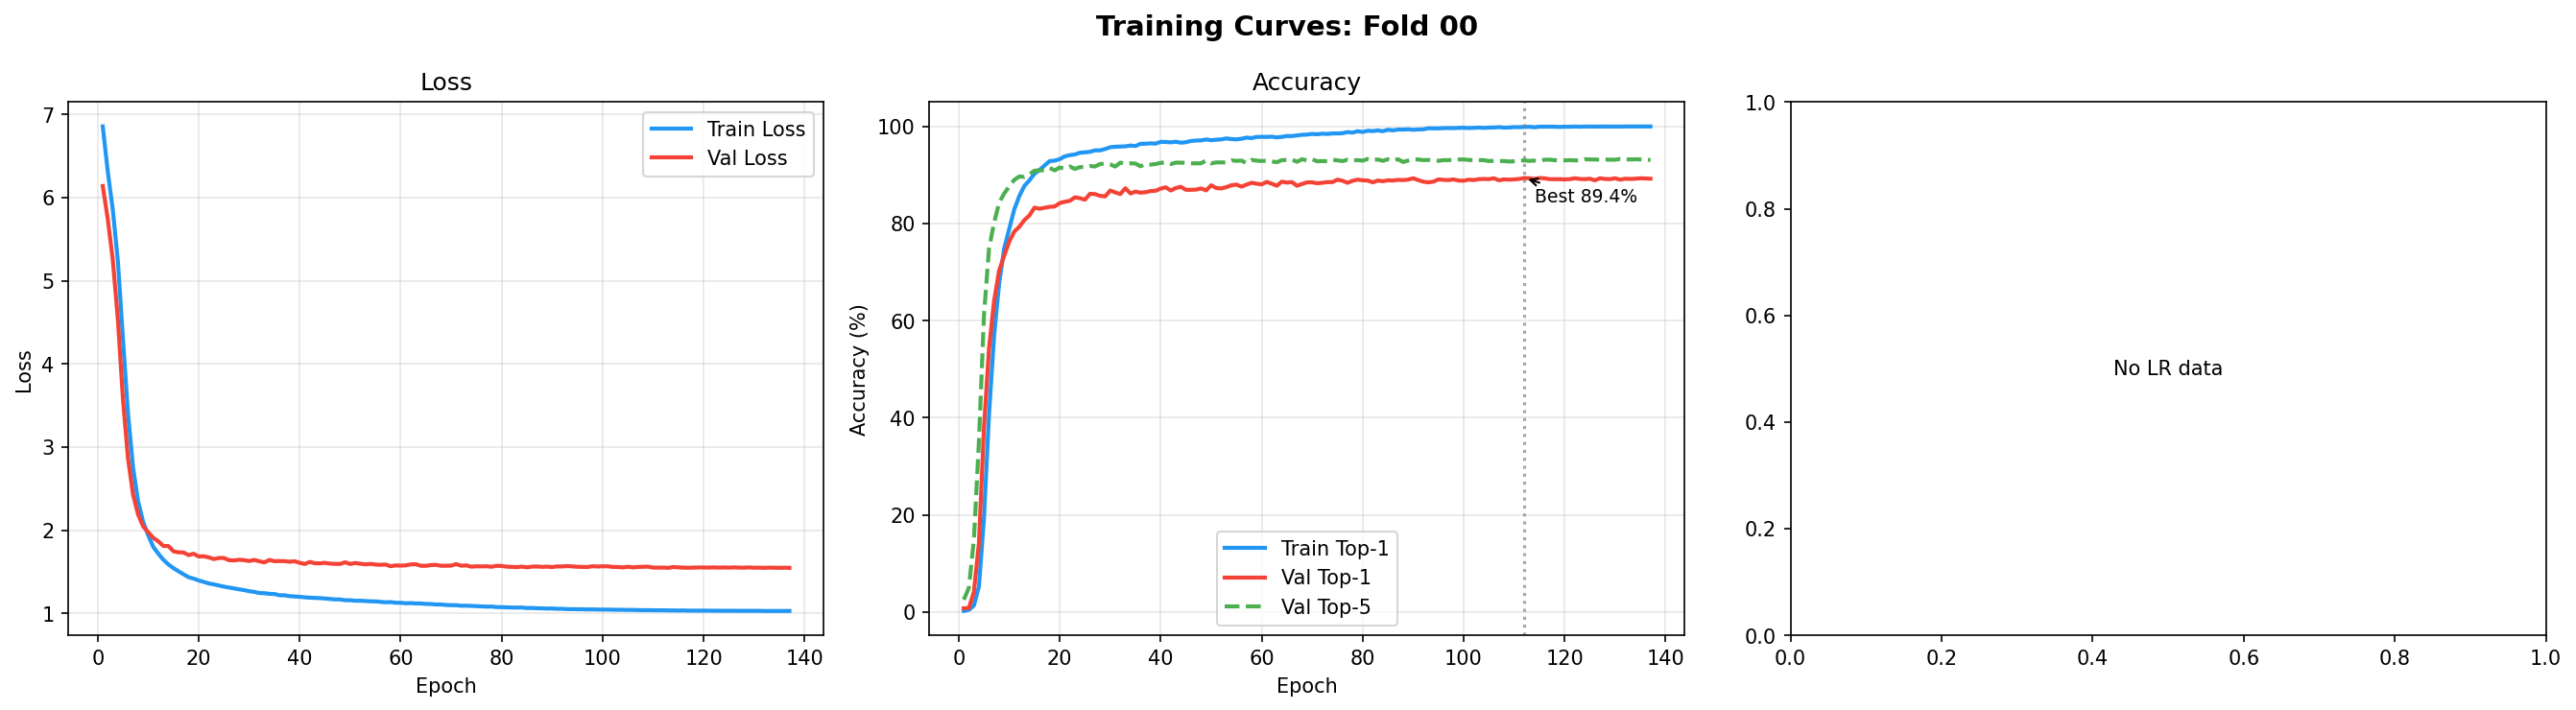

In [26]:
image_path = f'{RESULTS_DIR}/exp_cv_bilstm/fold_00/training_curves.png'
display(Image(filename=image_path))

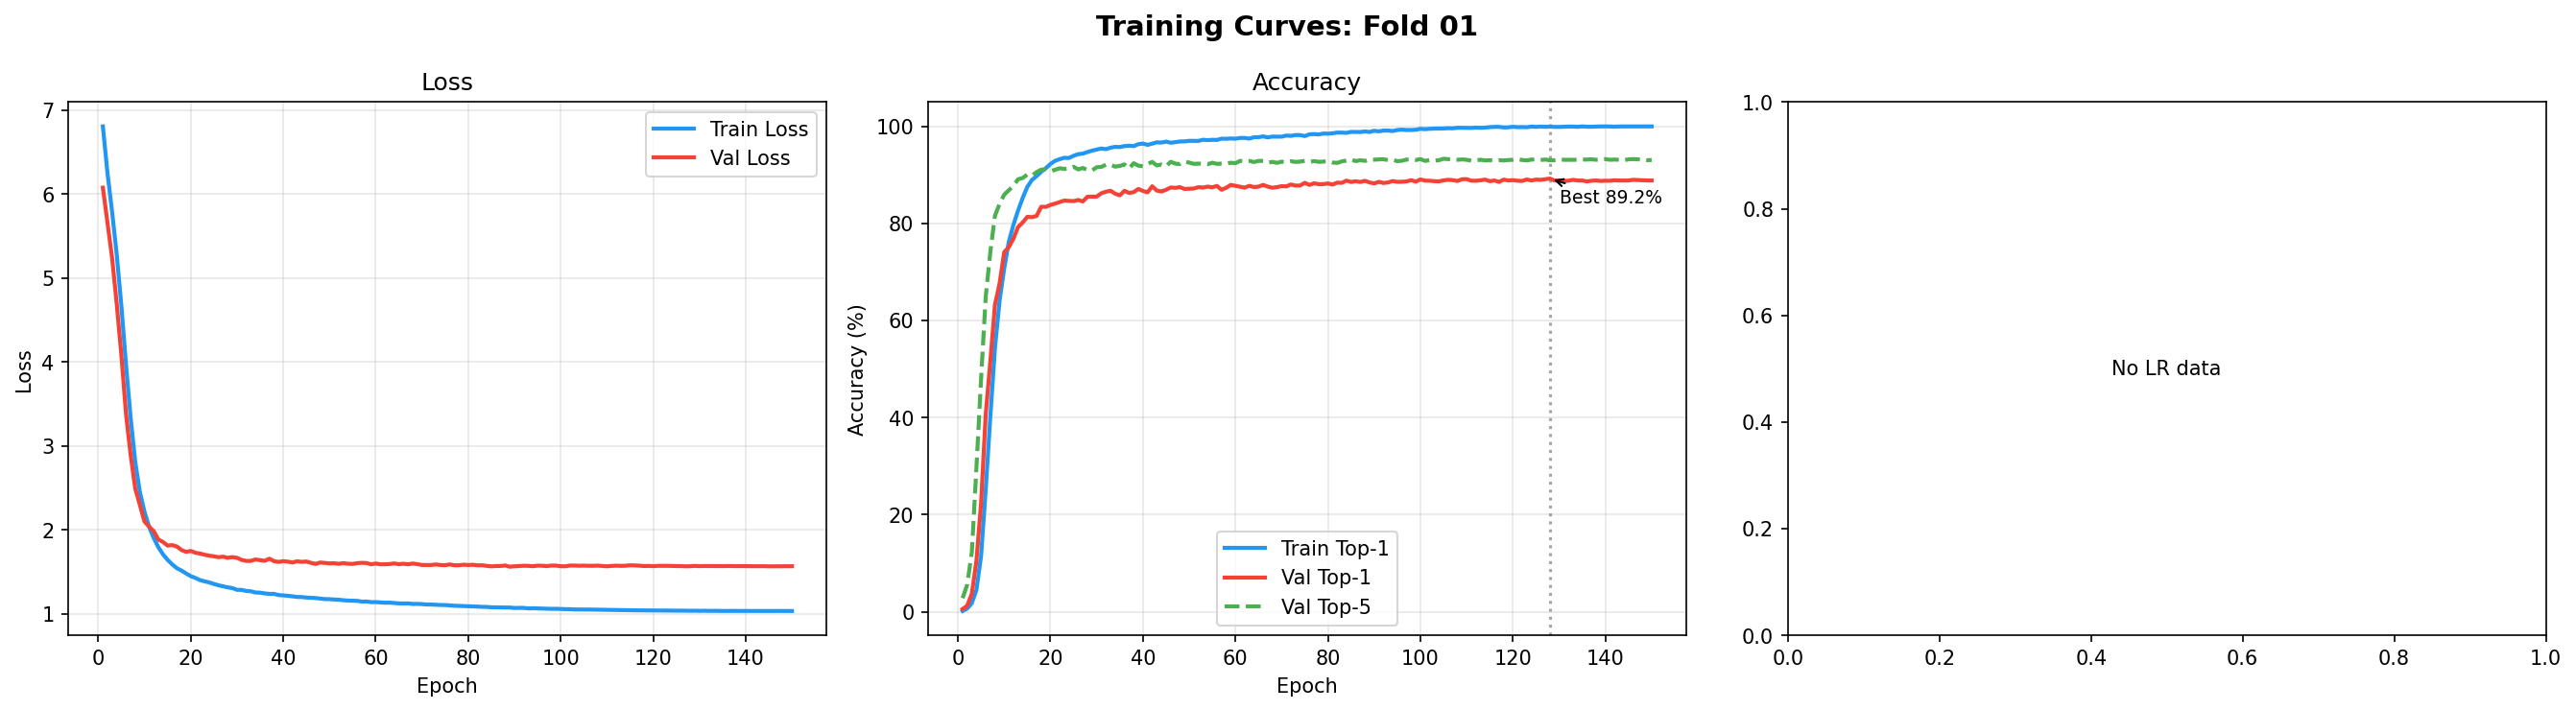

In [27]:
image_path = f'{RESULTS_DIR}/exp_cv_bilstm/fold_01/training_curves.png'
display(Image(filename=image_path))

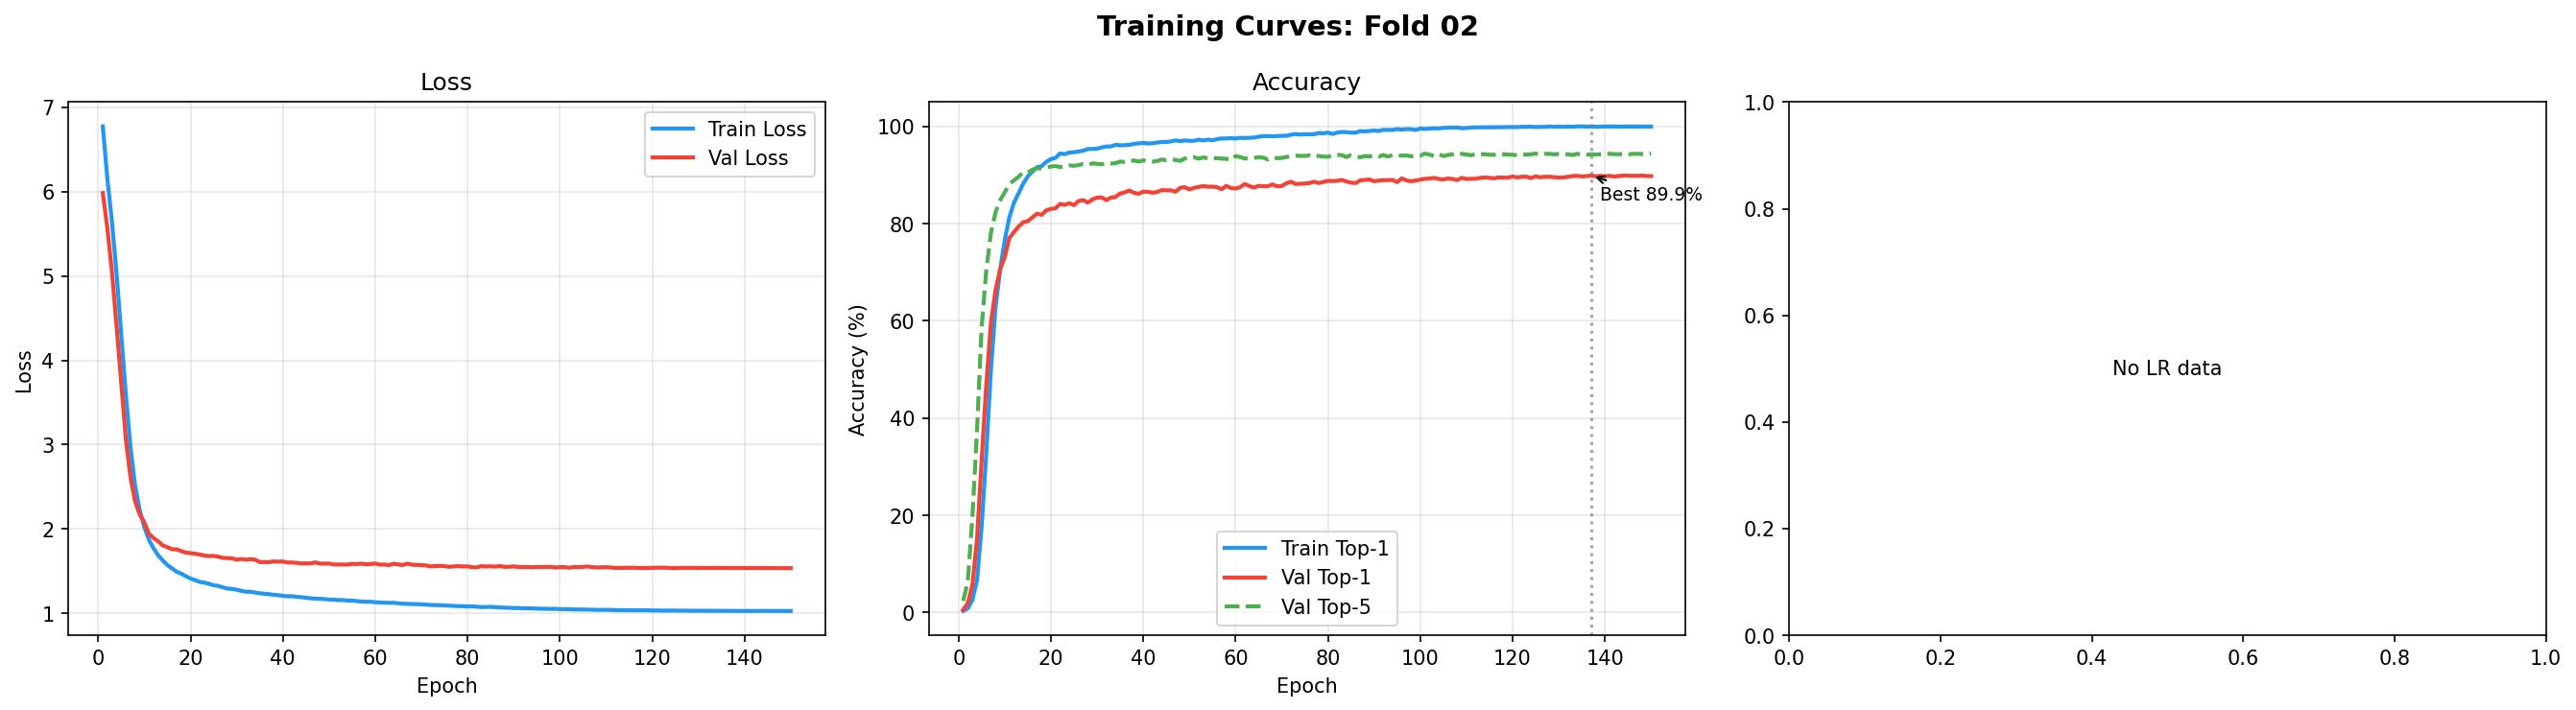

In [28]:
image_path = f'{RESULTS_DIR}/exp_cv_bilstm/fold_02/training_curves.png'
display(Image(filename=image_path))

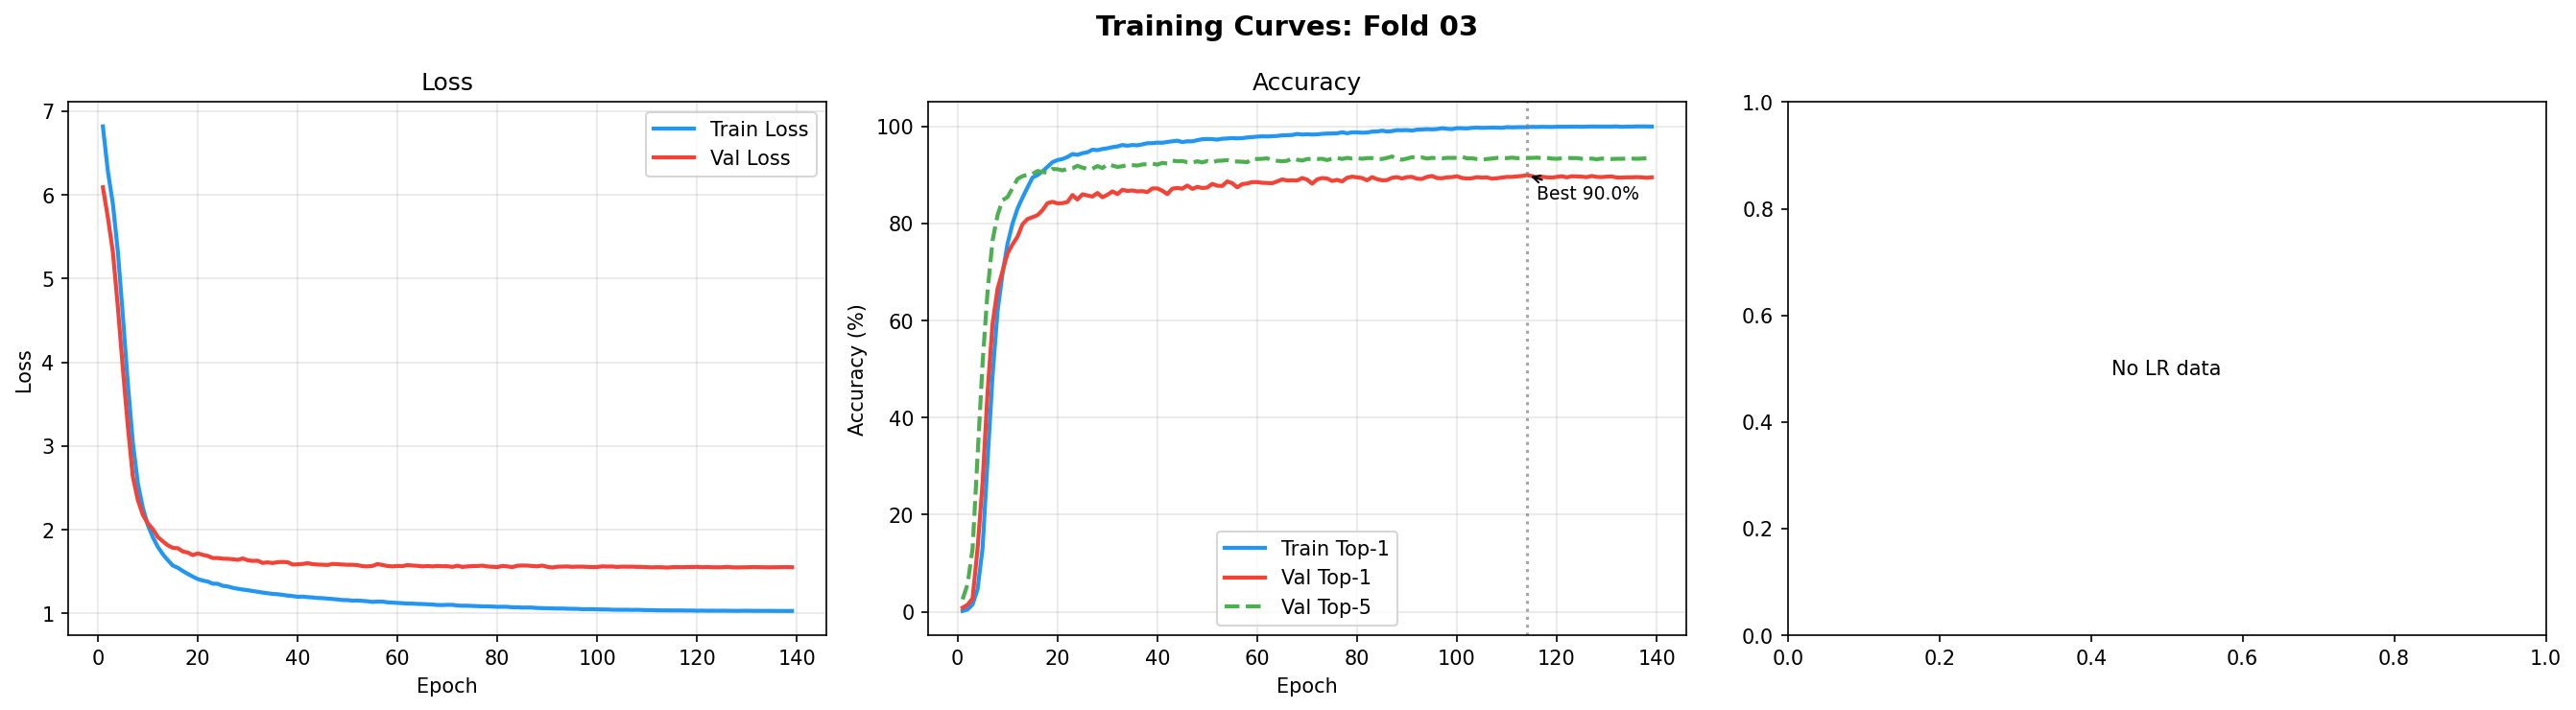

In [29]:
image_path = f'{RESULTS_DIR}/exp_cv_bilstm/fold_03/training_curves.png'
display(Image(filename=image_path))

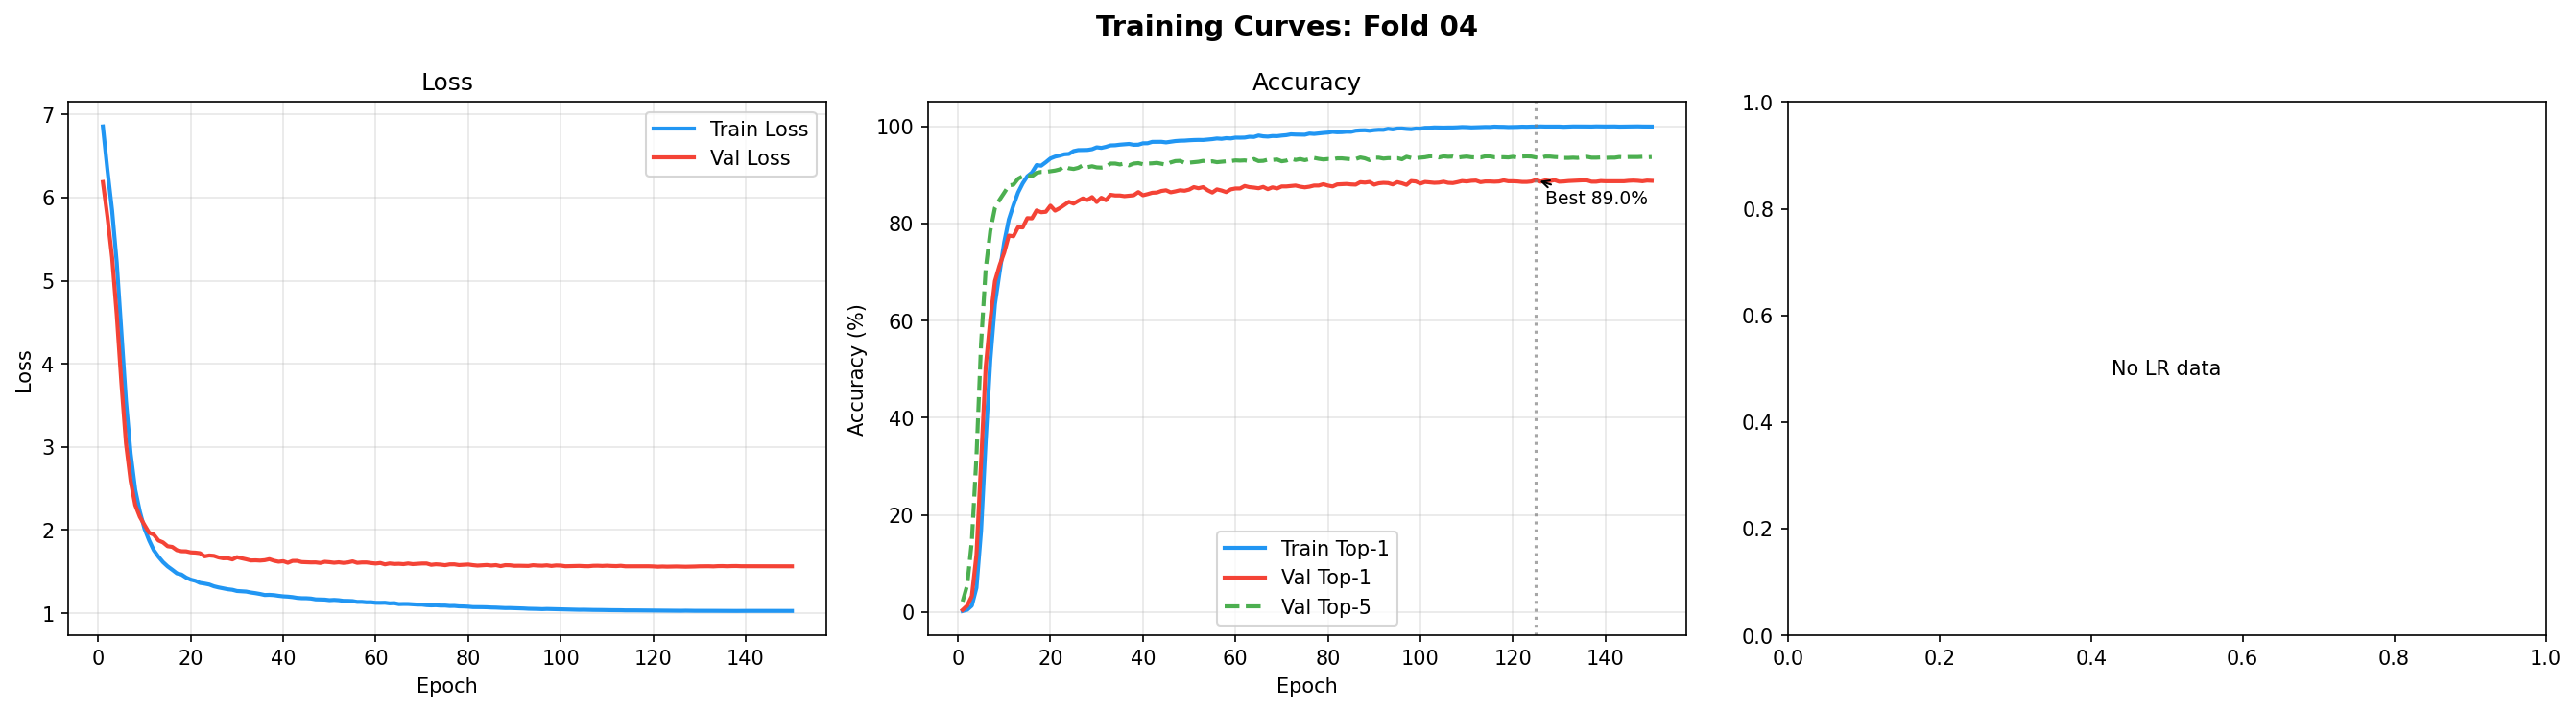

In [30]:
image_path = f'{RESULTS_DIR}/exp_cv_bilstm/fold_04/training_curves.png'
display(Image(filename=image_path))

#### Transformer 5-fold Cross Validation

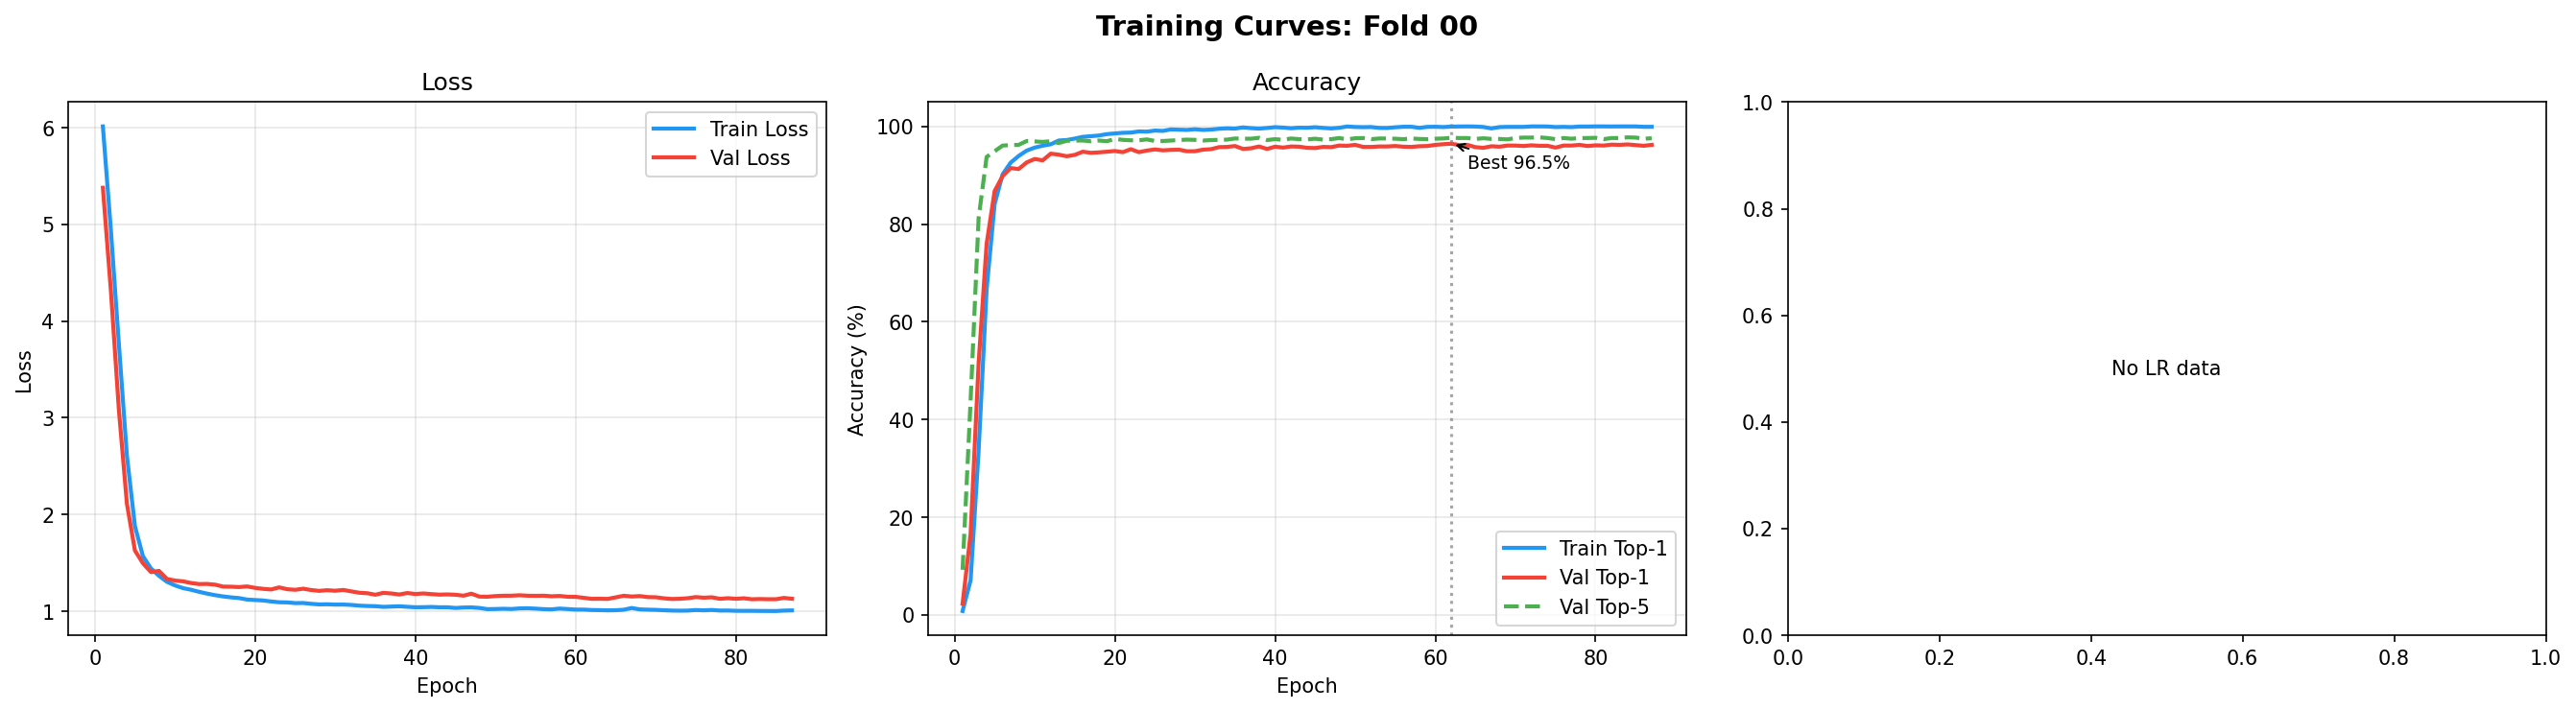

In [31]:
image_path = f'{RESULTS_DIR}/exp_cv_transformer/fold_00/training_curves.png'
display(Image(filename=image_path))

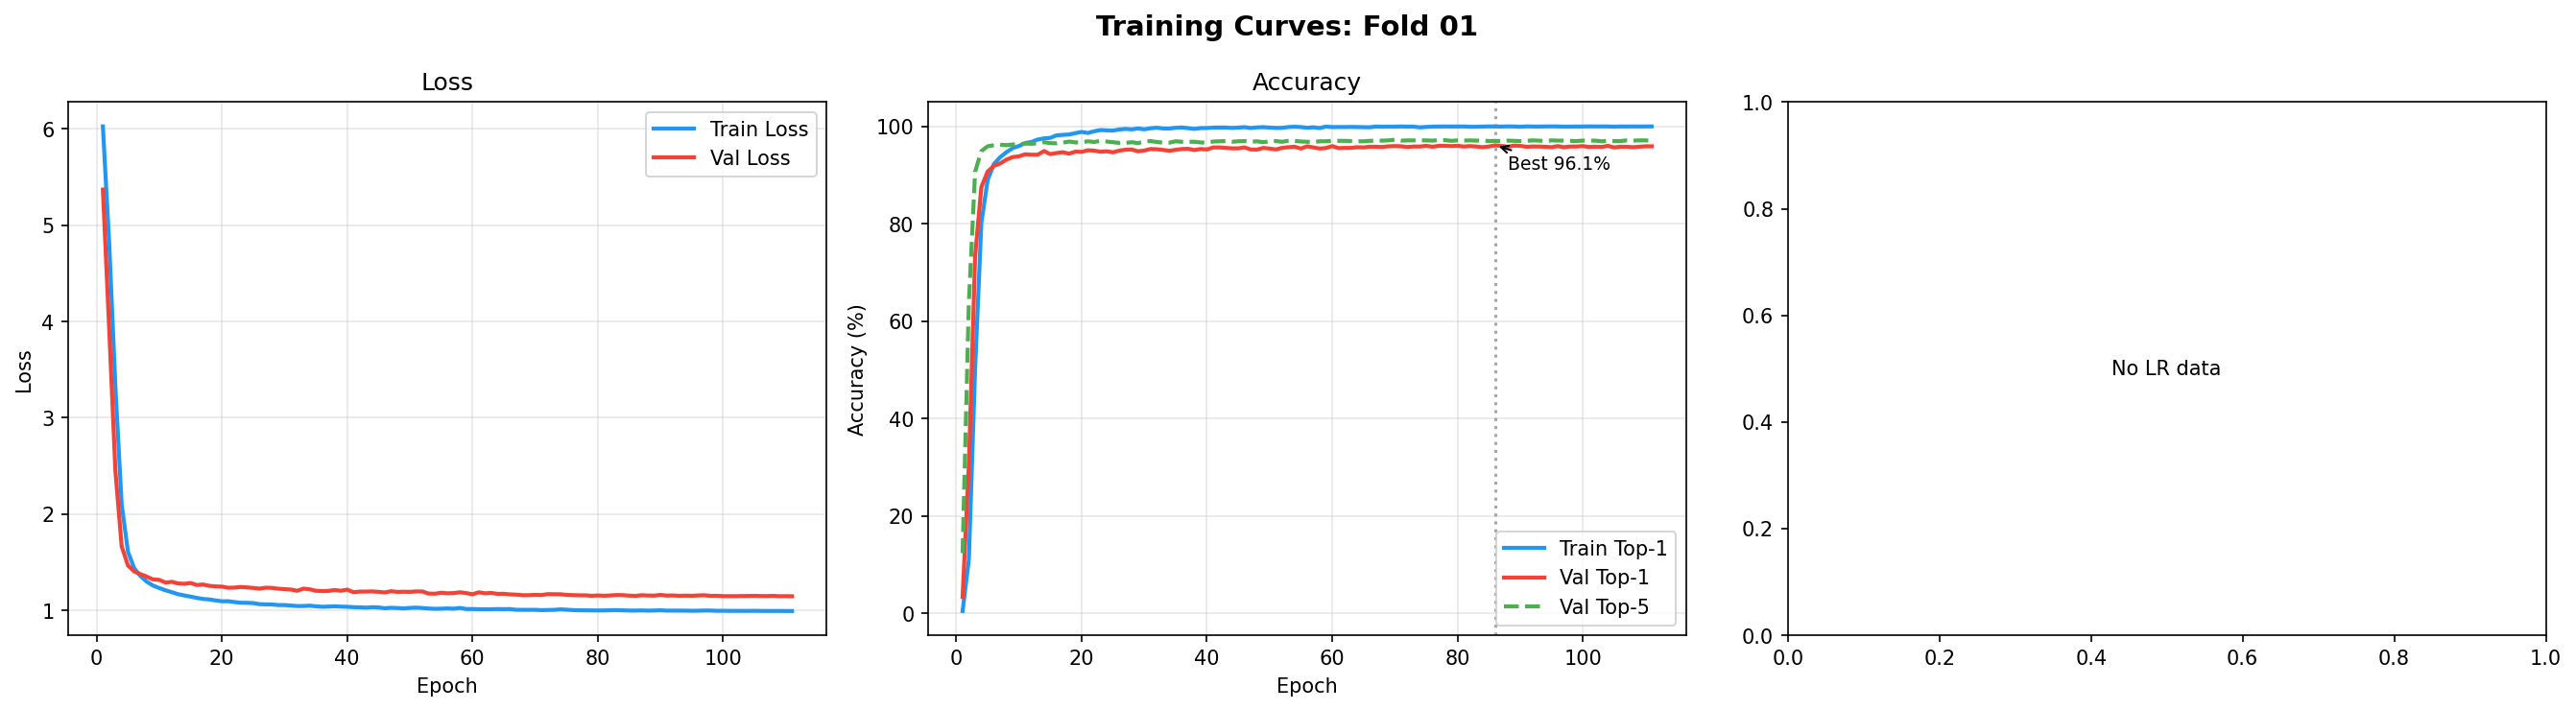

In [32]:
image_path = f'{RESULTS_DIR}/exp_cv_transformer/fold_01/training_curves.png'
display(Image(filename=image_path))

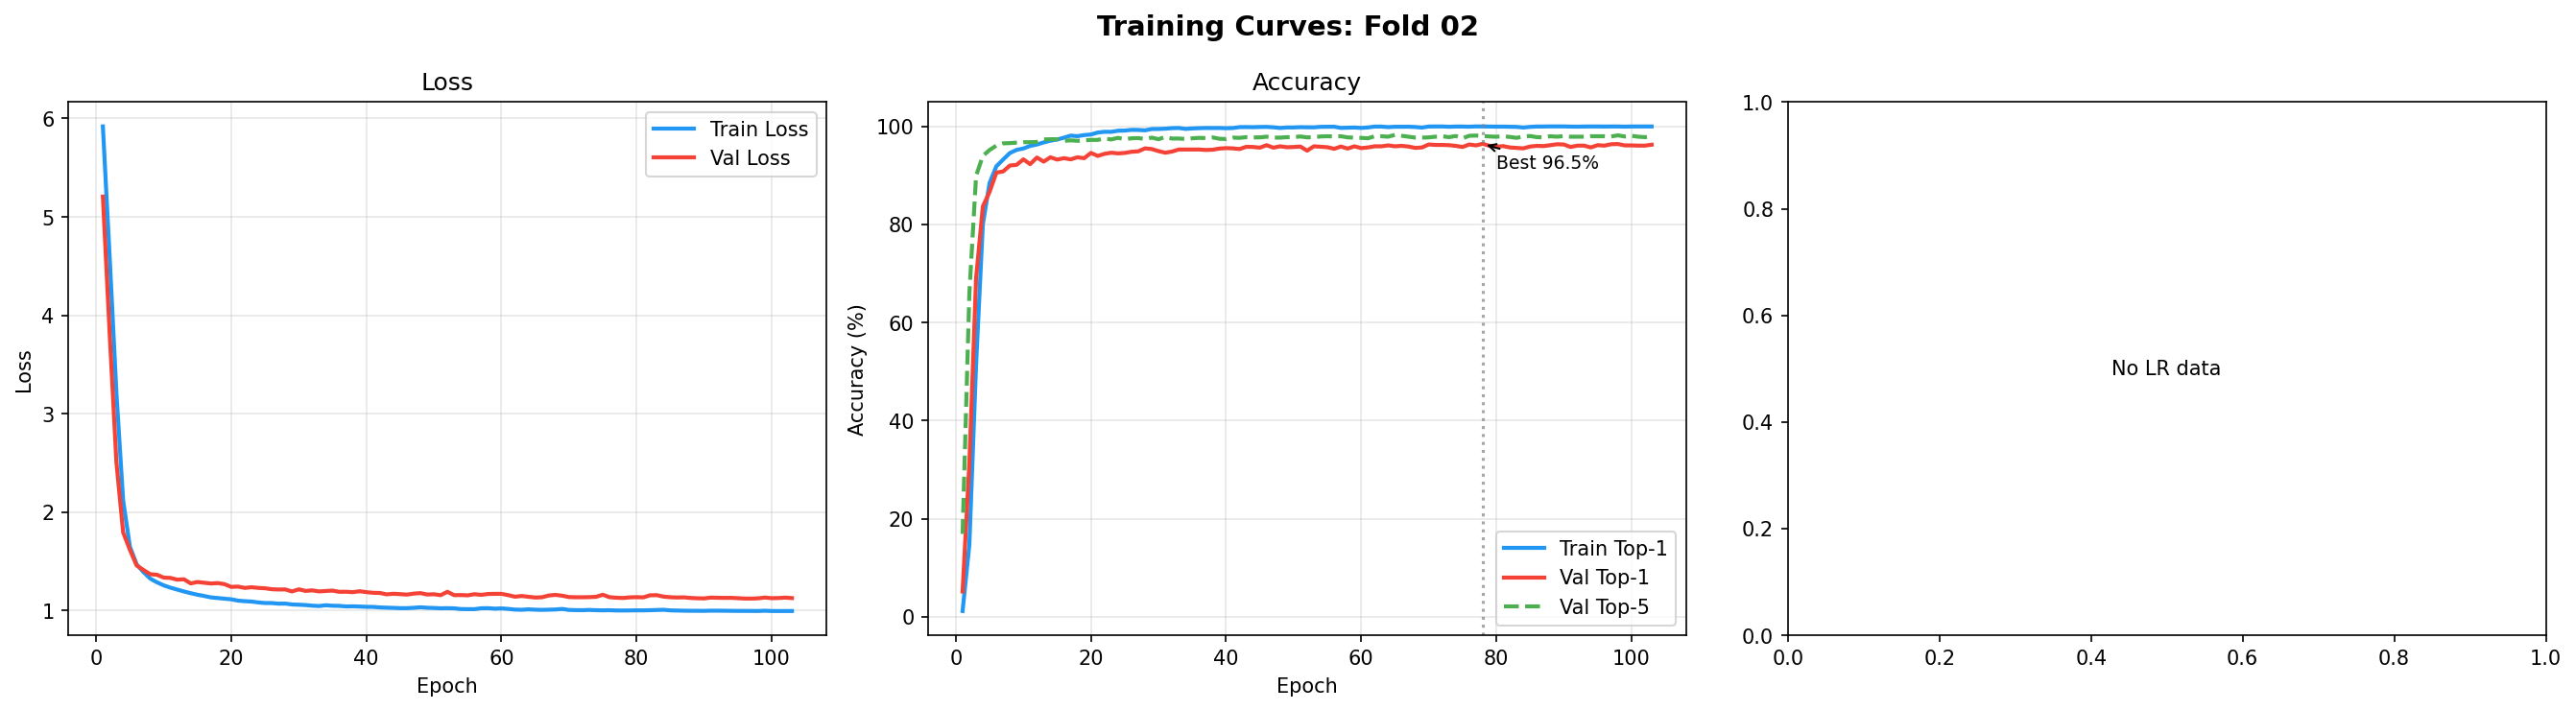

In [33]:
image_path = f'{RESULTS_DIR}/exp_cv_transformer/fold_02/training_curves.png'
display(Image(filename=image_path))

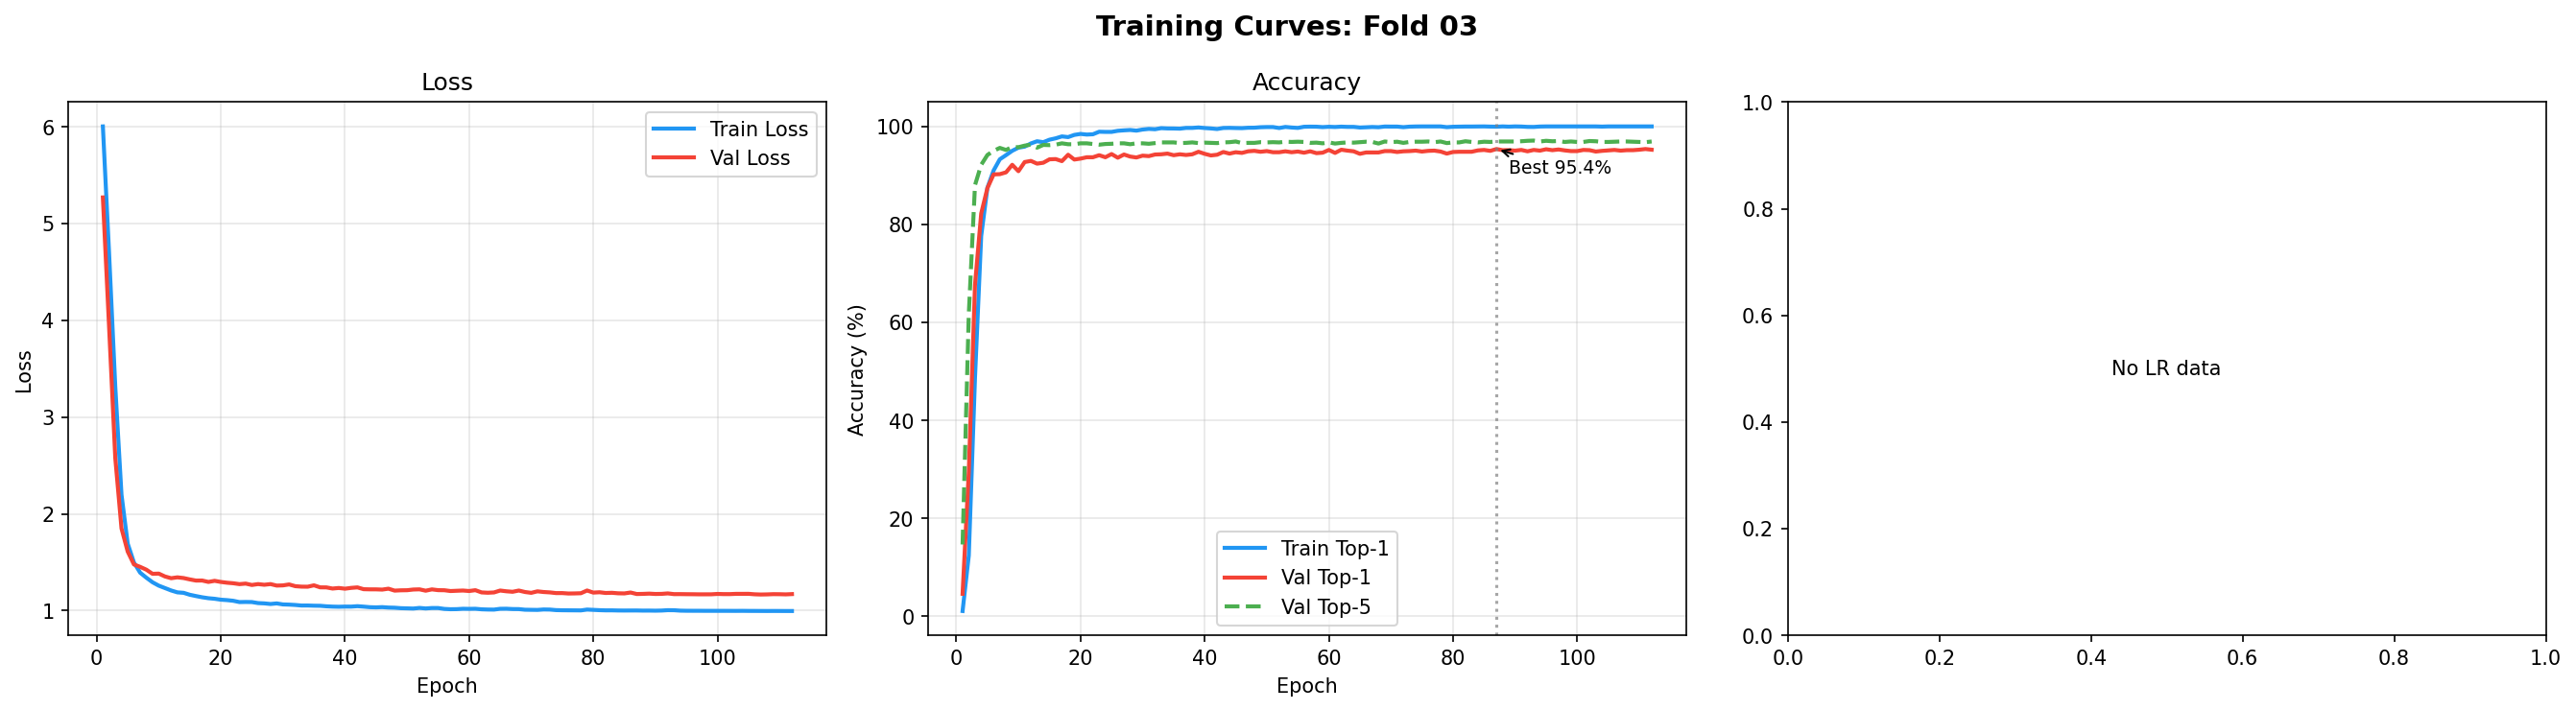

In [34]:
image_path = f'{RESULTS_DIR}/exp_cv_transformer/fold_03/training_curves.png'
display(Image(filename=image_path))

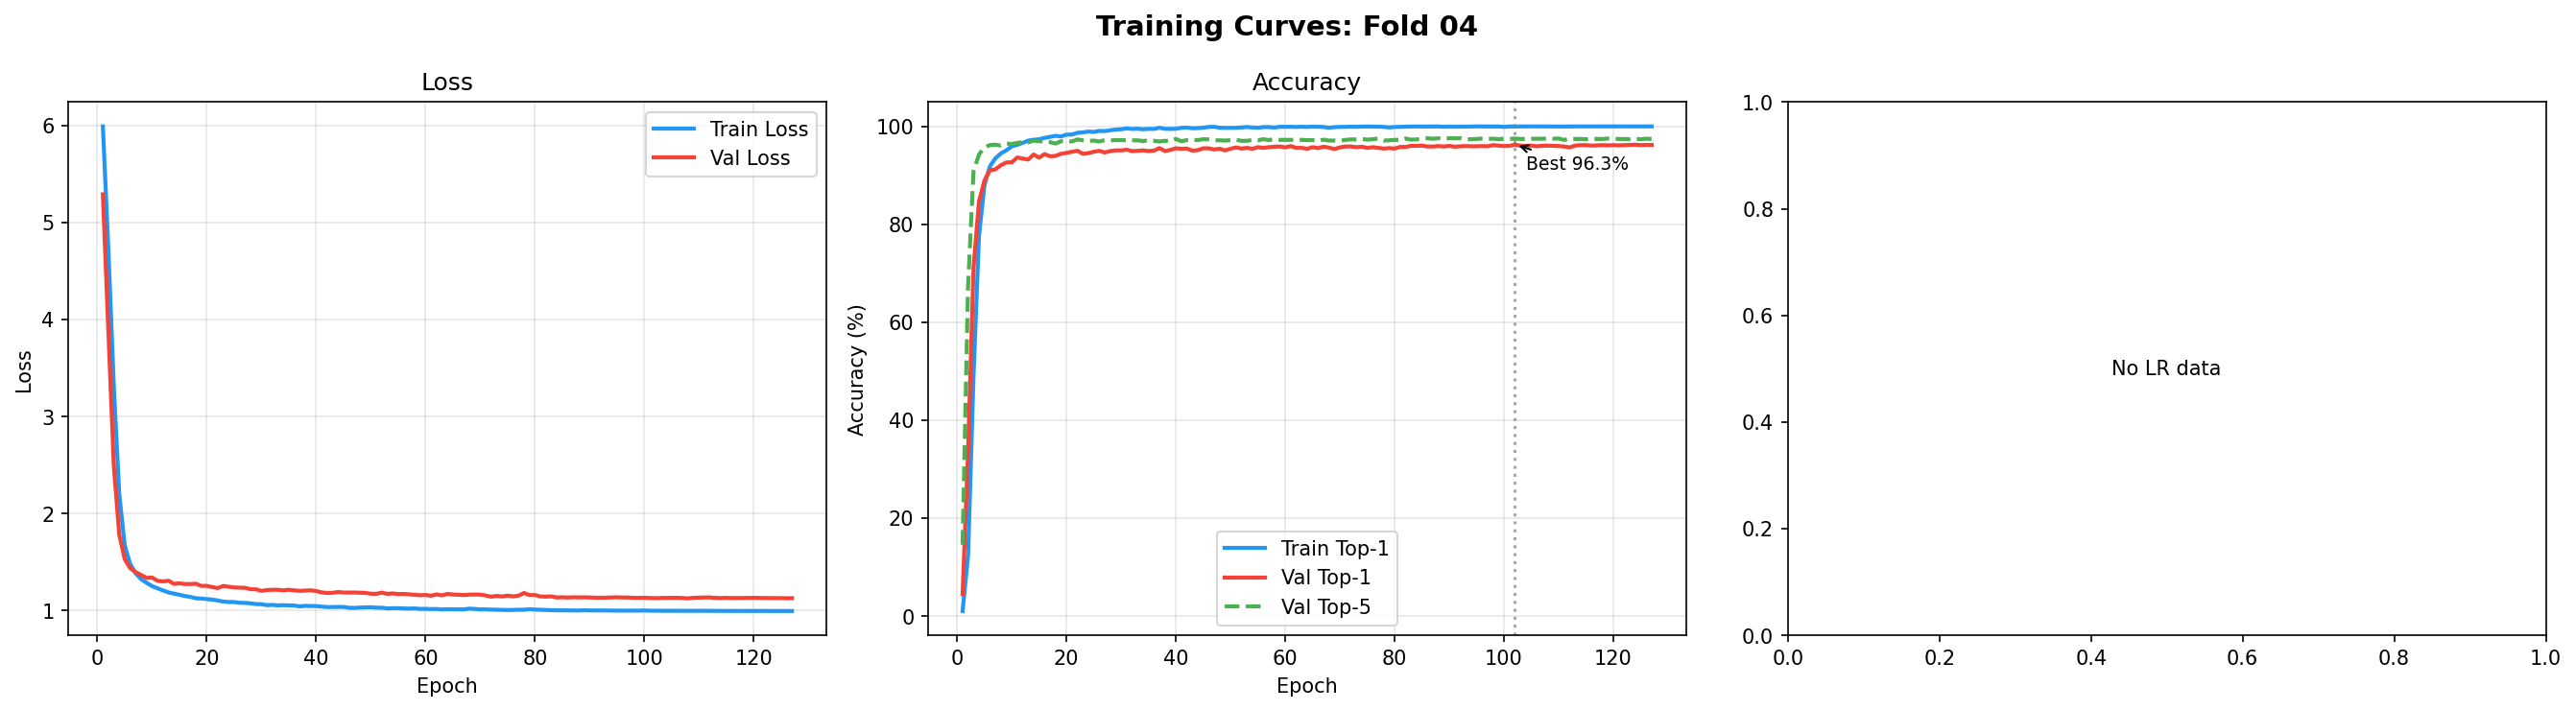

In [35]:
image_path = f'{RESULTS_DIR}/exp_cv_transformer/fold_04/training_curves.png'
display(Image(filename=image_path))

#### ST-GCN 5-fold Cross Validation

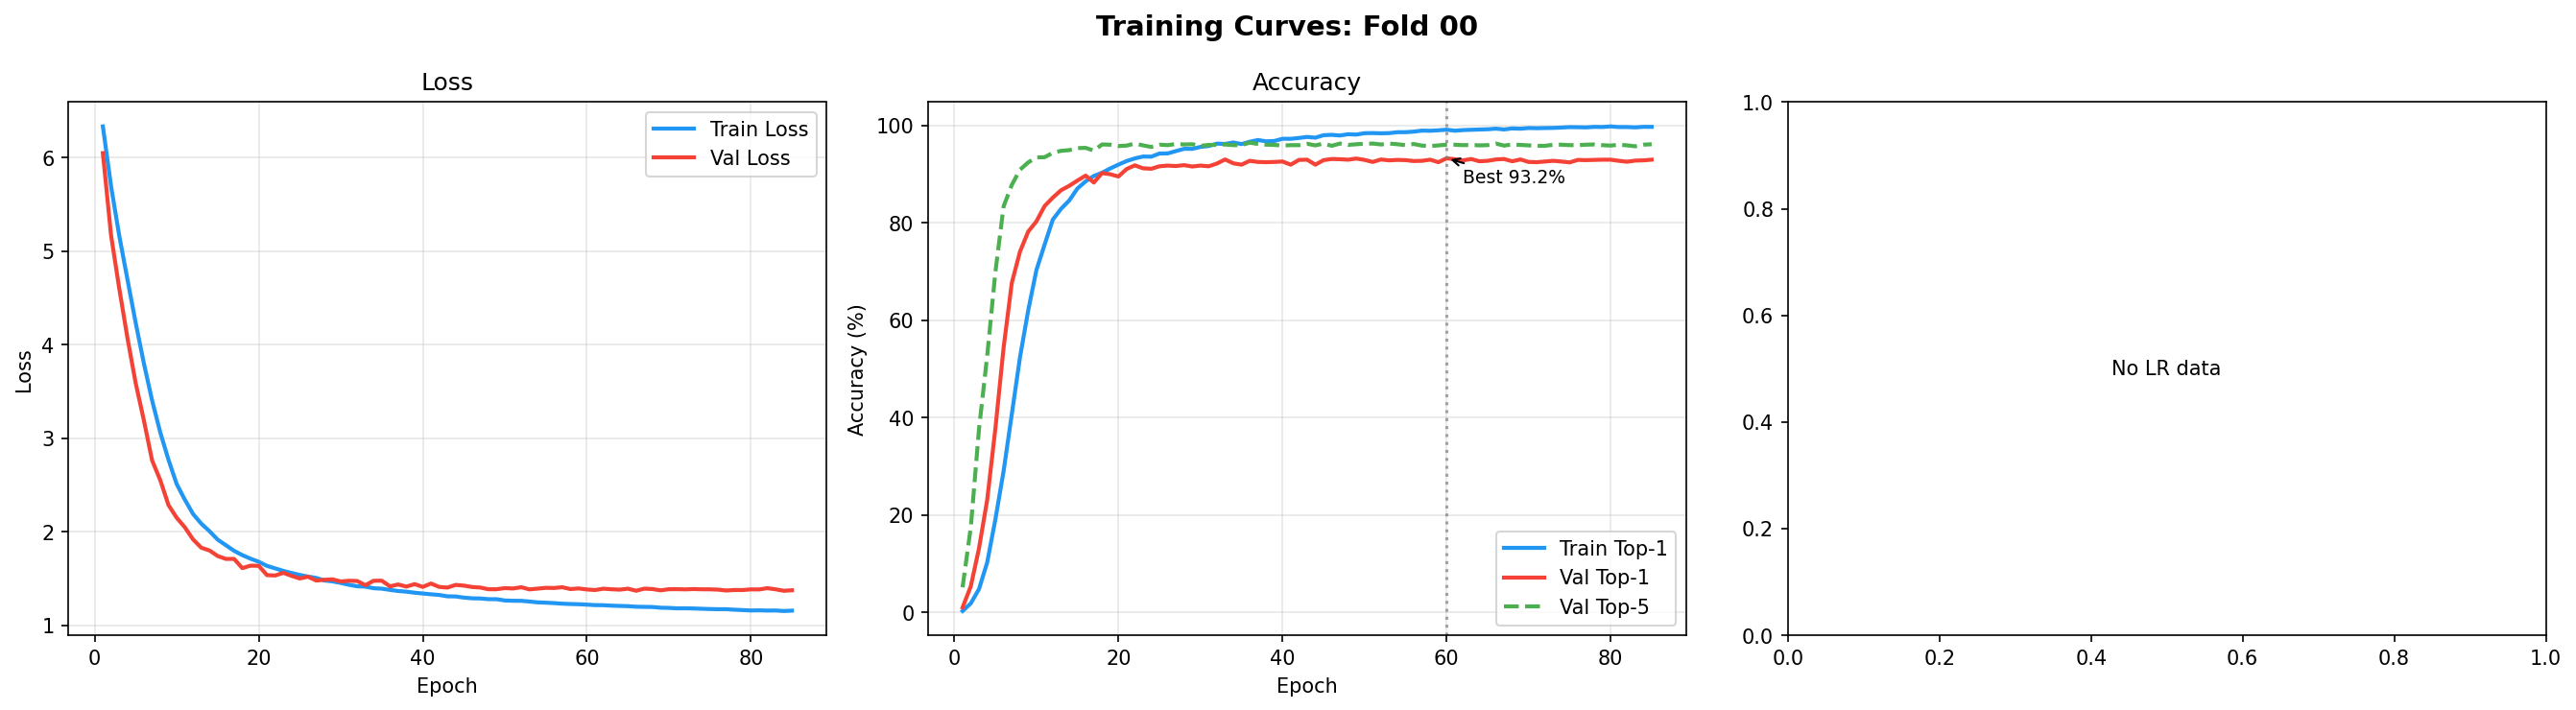

In [36]:
image_path = f'{RESULTS_DIR}/exp_cv_stgcn/fold_00/training_curves.png'
display(Image(filename=image_path))

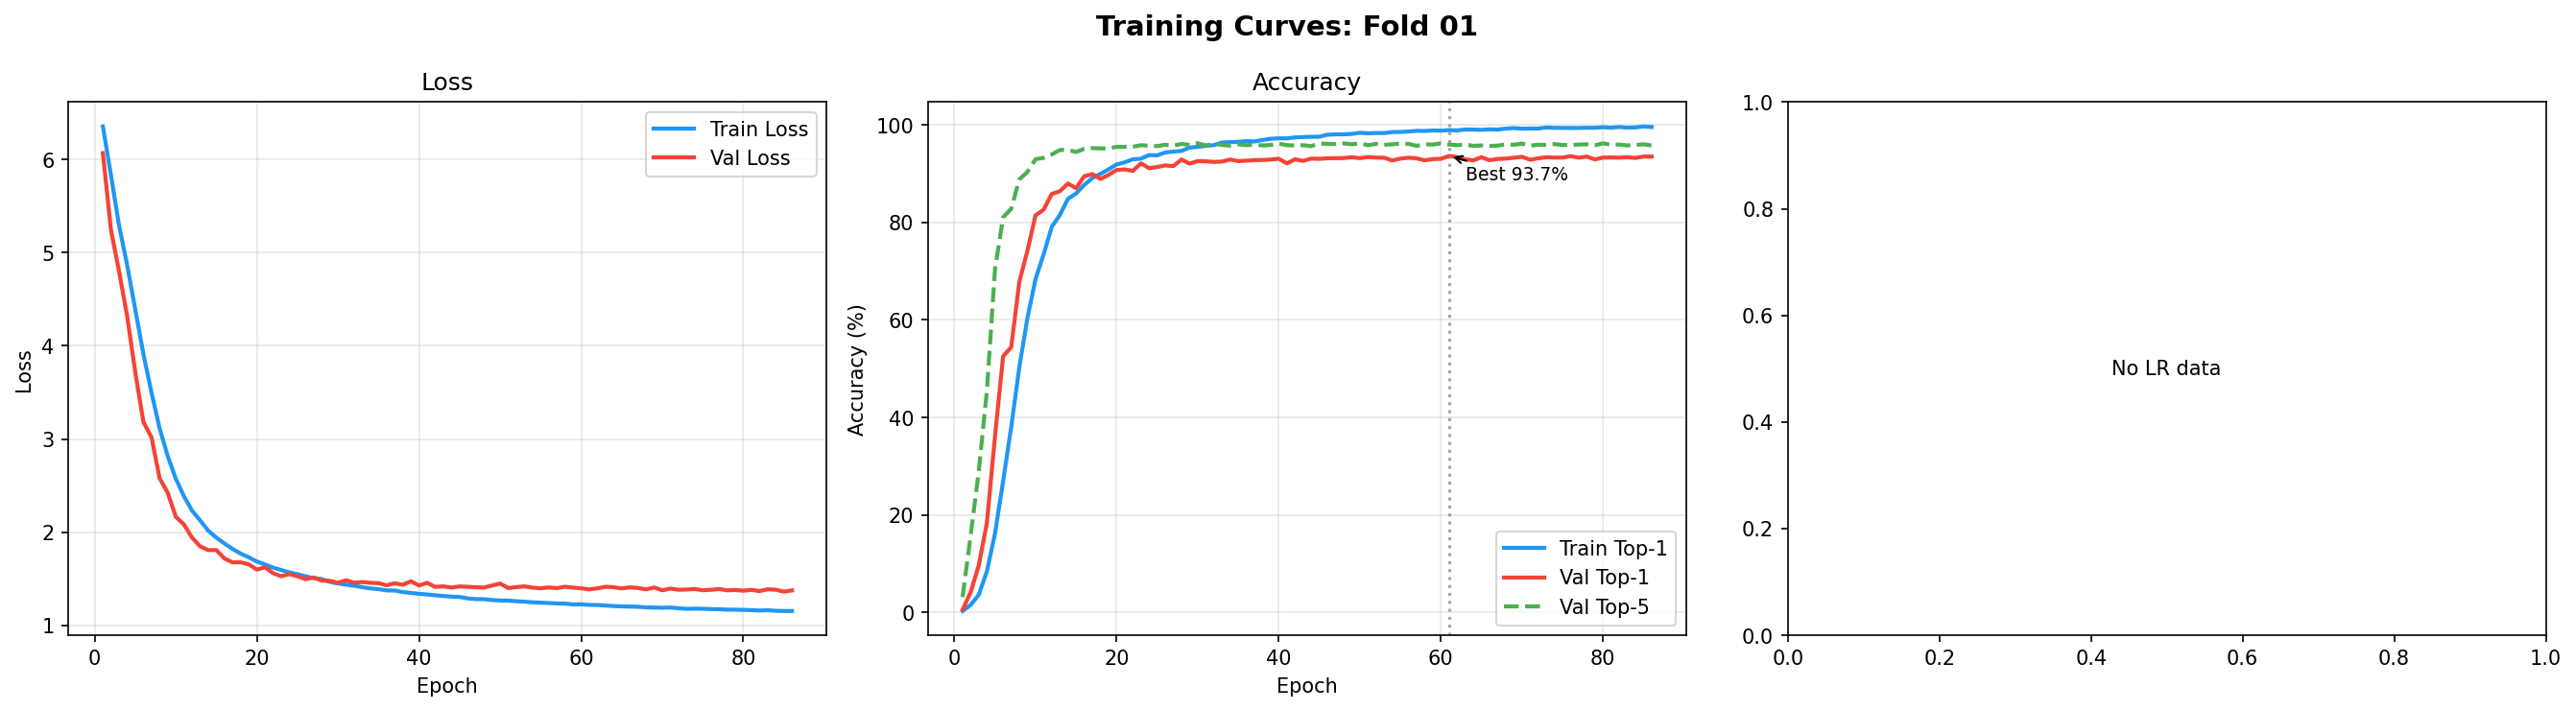

In [37]:
image_path = f'{RESULTS_DIR}/exp_cv_stgcn/fold_01/training_curves.png'
display(Image(filename=image_path))

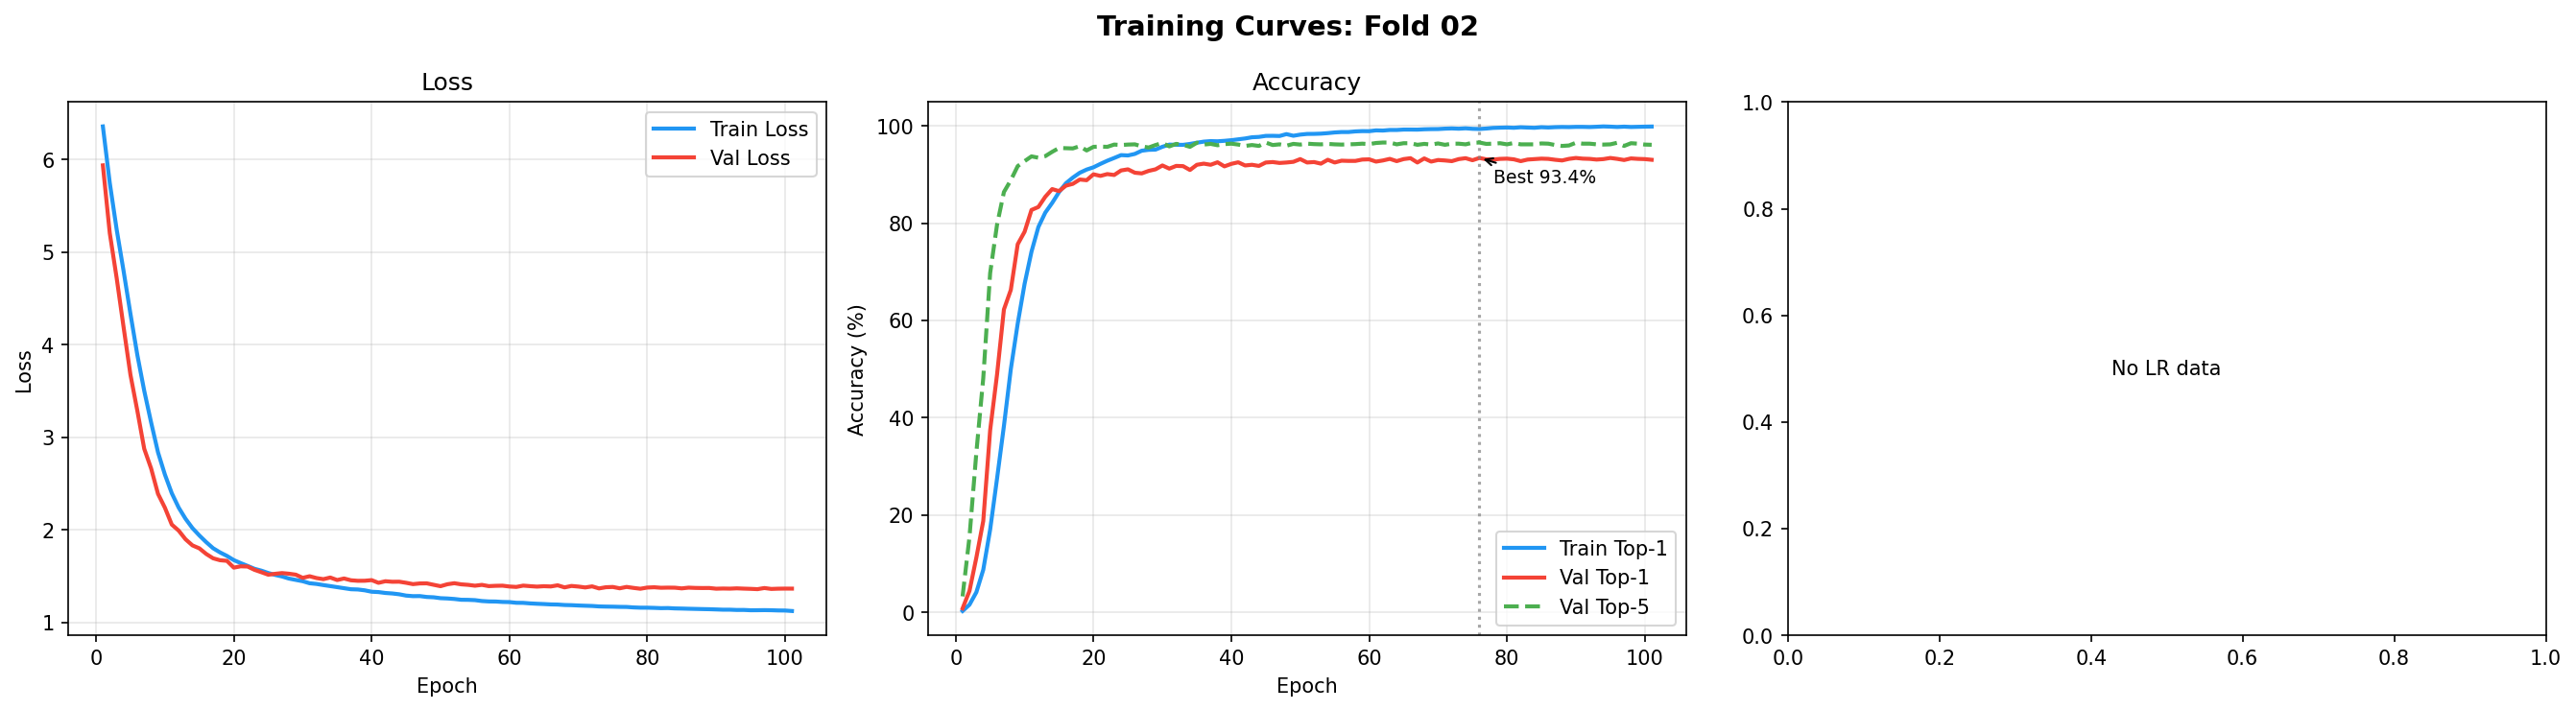

In [38]:
image_path = f'{RESULTS_DIR}/exp_cv_stgcn/fold_02/training_curves.png'
display(Image(filename=image_path))

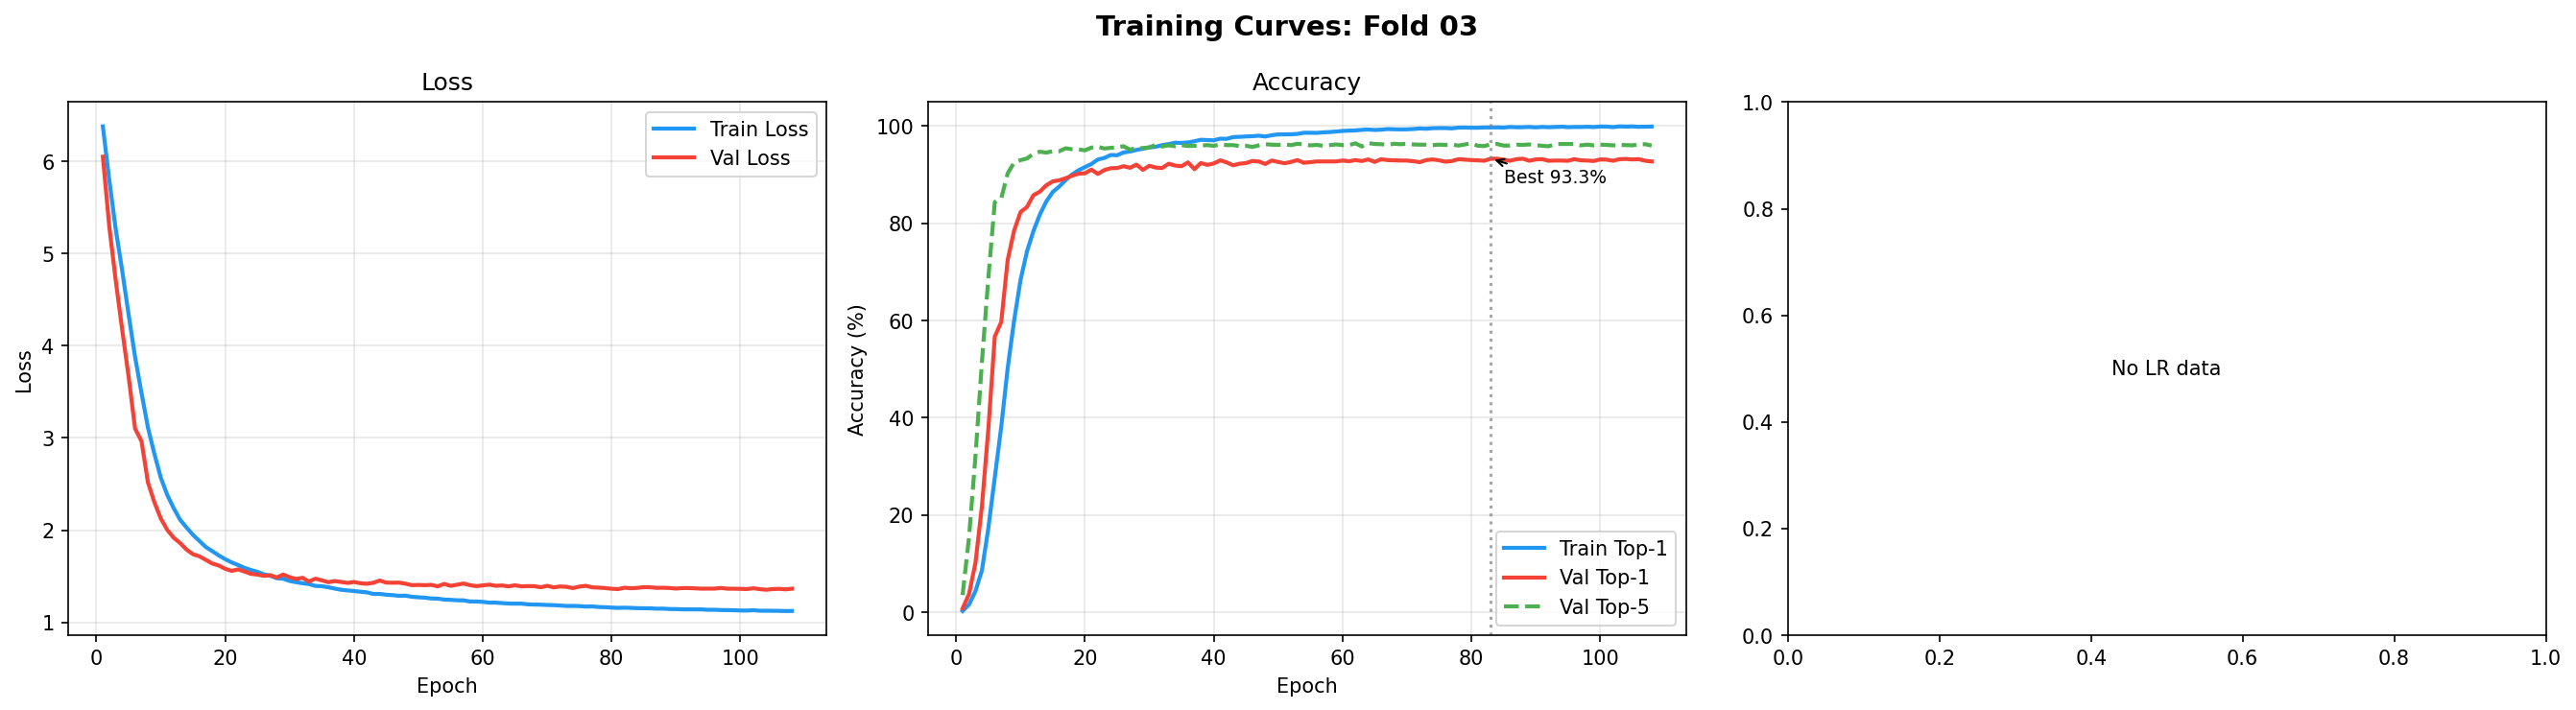

In [39]:
image_path = f'{RESULTS_DIR}/exp_cv_stgcn/fold_03/training_curves.png'
display(Image(filename=image_path))

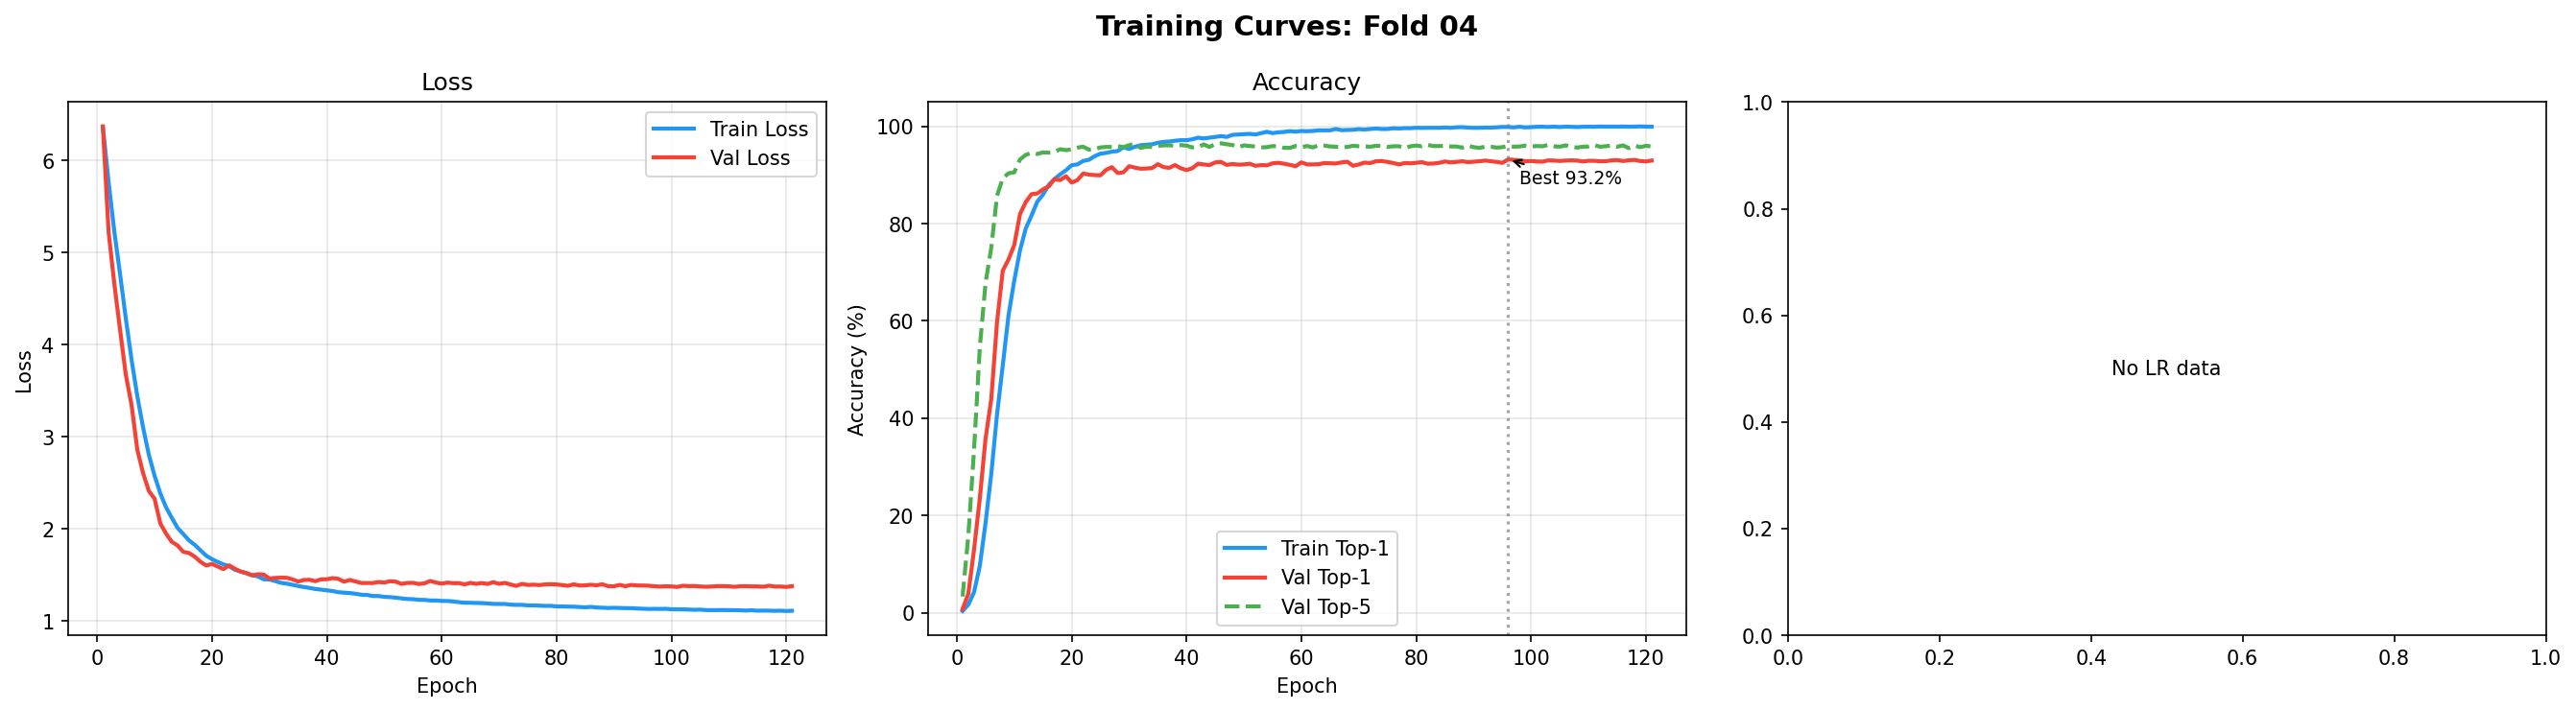

In [40]:
image_path = f'{RESULTS_DIR}/exp_cv_stgcn/fold_04/training_curves.png'
display(Image(filename=image_path))

### Model Comparison

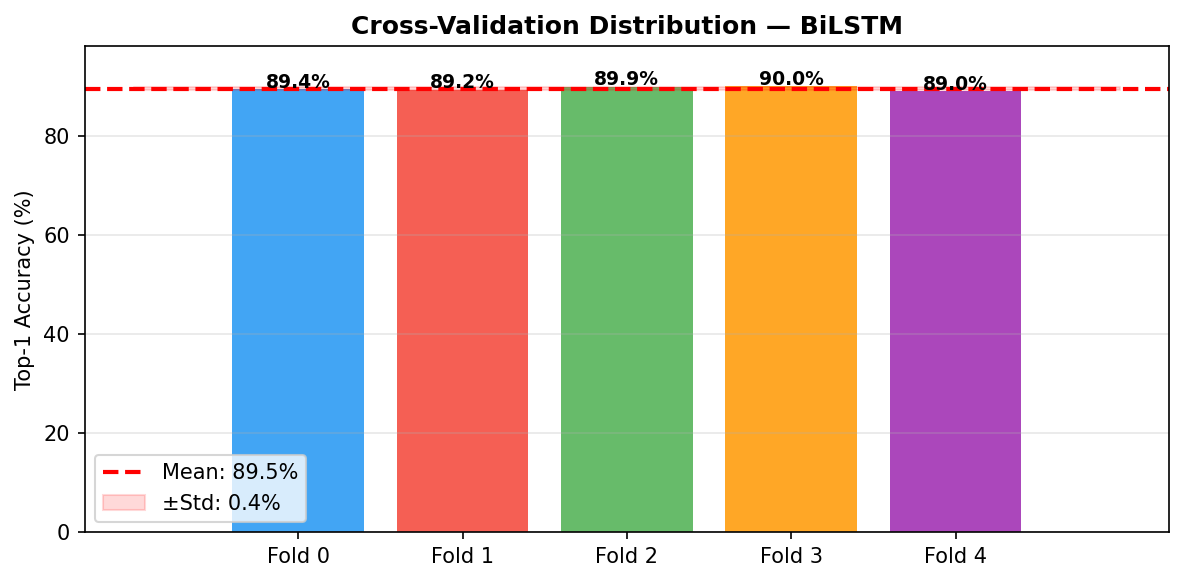

In [41]:
image_path = f'{RESULTS_DIR}/exp_cv_bilstm/cv_distribution.png'
display(Image(filename=image_path, width=400, height=200))

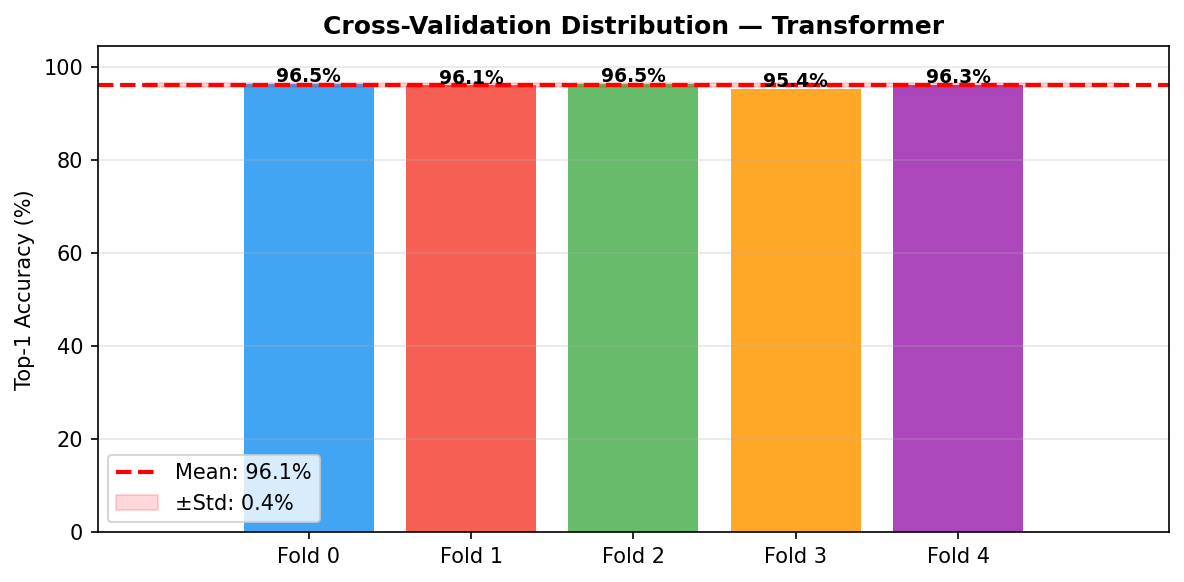

In [42]:
image_path = f'{RESULTS_DIR}/exp_cv_transformer/cv_distribution.png'
display(Image(filename=image_path, width=400, height=200))

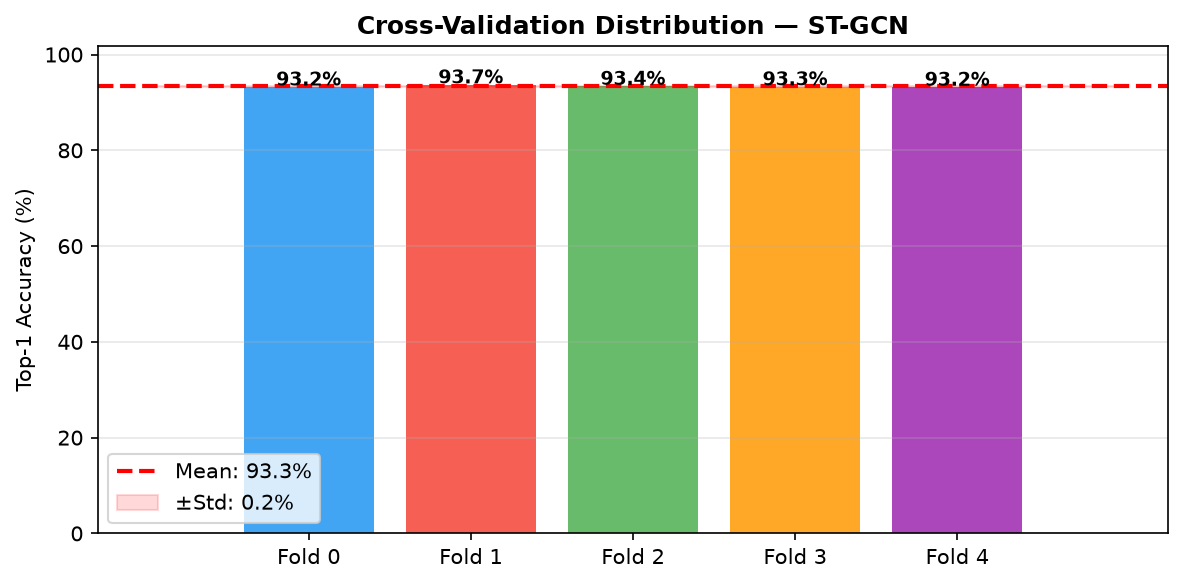

In [43]:
image_path = f'{RESULTS_DIR}/exp_cv_stgcn/cv_distribution.png'
display(Image(filename=image_path, width=400, height=200))

## 08. Inference

In [44]:
DATA_DIR = ROOT / "data"

In [45]:
import mediapipe as mp

In [46]:
%cd {ROOT}

/kaggle/working


### Inference with Multiple Videos

Sample videos:
- `data/sample4infer/idx20-101.mp4` $\rightarrow$ "ဖုန်းဆက် 199"
- `data/sample4infer/idx20-201.mp4` $\rightarrow$ "ကိုက် မြွေ အဆိပ်ရှိ ဆိုး"
- `data/sample4infer/idx20-301.mp4` $\rightarrow$ "ဖန်ကွဲစ ရှမိပြီး သွေးတွေတအားထွက်နေ"
- `data/sample4infer/idx20-401.mp4` $\rightarrow$ "ကျွန်တော် တစ်ကိုယ်လုံး ကိုက်ခဲနေတယ်"
- `data/sample4infer/idx20-501.mp4` $\rightarrow$ "ပလာစတာ တစ်ခု လိုချင်လို့ပါ"

In [47]:
# BiLSTM
# best model for exp_cv_bilstm is from fold 03
!python {SRC_DIR}/infer.py \
  --checkpoint {RESULTS_DIR}/exp_cv_bilstm/fold_03/best.pth \
  --config {CONFIG} \
  --batch {DATA_DIR}/sample4infer/ \
  --output {RESULTS_DIR}/inference_sample4infer_cv_bilstm_v1.csv \
  --top_k 5

2026-06-23 20:40:46 | INFO     | infer | Loaded bilstm from /kaggle/working/results/exp_cv_bilstm/fold_03/best.pth
I0000 00:00:1782222046.770363   72409 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782222046.776150   72479 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
I0000 00:00:1782222046.786768   72409 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782222046.789500   72494 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1782222046.886134   72480 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782222046.964910   72490 inference_feedback_manager.cc:114] Feedback manager

In [48]:
# Transformer
# best model for exp_cv_transformer is from fold 00
!python {SRC_DIR}/infer.py \
  --checkpoint {RESULTS_DIR}/exp_cv_transformer/fold_00/best.pth \
  --config {CONFIG} \
  --batch data/sample4infer/ \
  --output {RESULTS_DIR}/inference_sample4infer_cv_transformer_v1.csv \
  --top_k 5

2026-06-23 20:42:23 | INFO     | infer | Loaded transformer from /kaggle/working/results/exp_cv_transformer/fold_00/best.pth
I0000 00:00:1782222144.085366   72601 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782222144.090955   72669 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
I0000 00:00:1782222144.100533   72601 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782222144.104094   72684 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1782222144.191643   72671 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782222144.236737   72679 inference_feedback_manager.cc:114] Feedba

In [49]:
# ST-GCN
# best model for exp_cv_stgcn is from fold 01
!python {SRC_DIR}/infer.py \
  --checkpoint {RESULTS_DIR}/exp_cv_stgcn/fold_01/best.pth \
  --config {CONFIG} \
  --batch {DATA_DIR}/sample4infer/ \
  --output {RESULTS_DIR}/inference_sample4infer_cv_stgcn_v1.csv \
  --top_k 5

2026-06-23 21:11:01 | INFO     | infer | Loaded stgcn from /kaggle/working/results/exp_cv_stgcn/fold_01/best.pth
I0000 00:00:1782223861.911585   74112 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782223861.918944   74173 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
I0000 00:00:1782223861.938375   74112 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782223861.941485   74188 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1782223862.004093   74178 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782223862.047483   74185 inference_feedback_manager.cc:114] Feedback manager r

## Export Experiments

Only individual files (not directories) in the Kaggle working directory can be downloaded directly. Therefore, files and folders must be compressed into a ZIP archive before downloading.

In [50]:
shutil.make_archive(
    f"{RESULTS_DIR}/exp_cv_bilstm",
    'zip',
    f"{RESULTS_DIR}/exp_cv_bilstm"
)

'/kaggle/working/results/exp_cv_bilstm.zip'

In [51]:
shutil.make_archive(
    f"{RESULTS_DIR}/exp_cv_transformer",
    'zip',
    f"{RESULTS_DIR}/exp_cv_transformer"
)

'/kaggle/working/results/exp_cv_transformer.zip'

In [52]:
shutil.make_archive(
    f"{RESULTS_DIR}/exp_cv_stgcn",
    'zip',
    f"{RESULTS_DIR}/exp_cv_stgcn"
)

'/kaggle/working/results/exp_cv_stgcn.zip'